In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

# Бельгийски франк

In [ ]:
df = files.upload()
df = pd.read_excel('RC_F01_07_1992_T06_12_2025.xlsx')
df

Saving RC_F01_07_1992_T06_12_2025.xlsx to RC_F01_07_1992_T06_12_2025.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,nominal,data,curs,cdx
0,100,2001-12-28,65.66,Бельгийский франк
1,100,2001-12-27,65.89,Бельгийский франк
2,100,2001-12-26,65.68,Бельгийский франк
3,100,2001-12-25,66.41,Бельгийский франк
4,100,2001-12-22,66.92,Бельгийский франк
...,...,...,...,...
1794,10,1992-07-15,42.65,Бельгийский франк
1795,10,1992-07-10,42.13,Бельгийский франк
1796,10,1992-07-08,41.95,Бельгийский франк
1797,10,1992-07-03,42.96,Бельгийский франк


In [ ]:
df.set_index('data', inplace = True)
df.head()

,nominal,curs,cdx
data,,,
2001-12-28,100,65.66,Бельгийский франк
2001-12-27,100,65.89,Бельгийский франк
2001-12-26,100,65.68,Бельгийский франк
2001-12-25,100,66.41,Бельгийский франк
2001-12-22,100,66.92,Бельгийский франк


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1799 entries, 2001-12-28 to 1992-07-01
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   nominal  1799 non-null   int64  
 1   curs     1799 non-null   float64
 2   cdx      1799 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 56.2+ KB


<Axes: xlabel='data'>

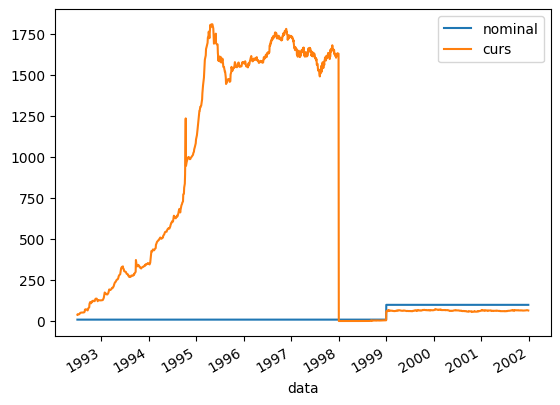

In [ ]:
df.plot()

Выводы:

- Высокая волатильность в первые годы (1992-1994)

- Сильный рост курса с 1992 по 1995 год

- Стабилизация с 1995 по 2001 год

- Необычные резкие изменения в 1997-1998 годах

1 января 1999 года был установлен безвозвратно фиксированный обменный курс: 1 евро = 40,3399 бельгийских франков, что ознаменовало начало первой фазы перехода — безналичного обращения евро. На этом этапе франк оставался основной наличной валютой, но все финансовые операции и безналичные расчеты могли проводиться в евро по фиксированному курсу. Вторая фаза началась 1 января 2002 года с введения в обращение банкнот и монет евро, что установило период параллельного обращения двух валют, который продлился два месяца. Завершающая фаза наступила 1 марта 2002 года, когда бельгийский франк окончательно утратил статус законного платежного средства, завершив более чем 170-летнюю историю национальной валюты Бельгии в рамках создания единого европейского валютного пространства.

Приведение к одному номиналу

In [ ]:
df['curs_adjusted'] = df['curs'].copy()

# Корректируем курс до 1999 года (изменение номинала 10:100 → коэффициент 10)
df.loc[df.index < '1999-01-01', 'curs_adjusted'] = df.loc[df.index < '1999-01-01', 'curs'] * 10

# Проверяем результат
df[['curs', 'curs_adjusted']].tail()

,curs,curs_adjusted
data,,
1992-07-15,42.65,426.5
1992-07-10,42.13,421.3
1992-07-08,41.95,419.5
1992-07-03,42.96,429.6
1992-07-01,39.92,399.2


<Axes: xlabel='data'>

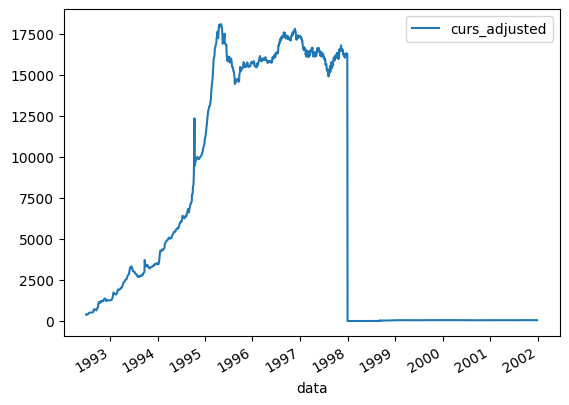

In [ ]:
df[['curs_adjusted']].plot()

Разделение на периоды

In [ ]:
periods_bef = {
    'Ранний период (до 1995)': ('1992-07-01', '1994-12-31'),
    'Стабилизация перед евро': ('1995-01-01', '1998-12-31'),
    'Фиксация к евро': ('1999-01-01', '2001-12-28')
}

df['period'] = None
for period_name, (start, end) in periods_bef.items():
    df.loc[(df.index >= start) & (df.index <= end), 'period'] = period_name

period_stats_bef = df.groupby('period')['curs_adjusted'].agg(['min', 'max', 'mean', 'std'])
print(period_stats_bef)

                             min       max          mean          std
period                                                               
Ранний период (до 1995)  399.200  12349.80   3946.541107  2798.830109
Стабилизация перед евро   15.843  18078.70  11153.824079  7594.131830
Фиксация к евро           57.200     73.98     64.753440     2.871318


Изменения частоты ряда

In [ ]:
df[['curs_adjusted']].resample(rule = 'YS').mean()

,curs_adjusted
data,
1992-01-01,908.241509
1993-01-01,2696.671717
1994-01-01,6766.015842
1995-01-01,15506.998990
1996-01-01,16780.718878
1997-01-01,16189.261080
1998-01-01,27.549390
1999-01-01,65.055800
2000-01-01,64.432510


<Axes: xlabel='data'>

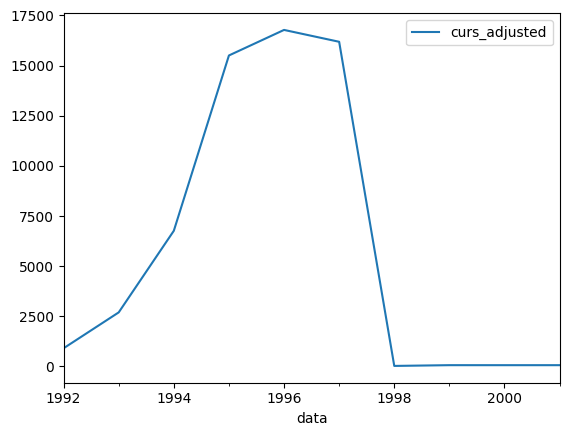

In [ ]:
df[['curs_adjusted']].resample(rule = 'YS').mean().plot()

In [ ]:
df[['curs_adjusted']].resample(rule = 'MS').mean().head()

,curs_adjusted
data,
1992-07-01,460.760000
1992-08-01,563.062500
1992-09-01,738.911111
1992-10-01,1162.355556
1992-11-01,1308.775000


<Axes: xlabel='data'>

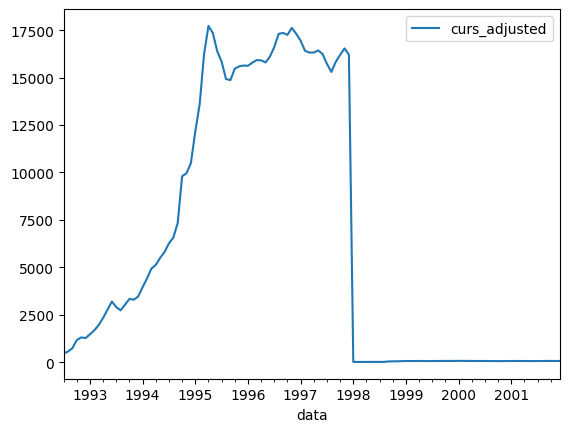

In [ ]:
df[['curs_adjusted']].resample(rule = 'MS').mean().plot()

In [ ]:
df[['curs_adjusted']].resample(rule = 'QS').mean().head()

,curs_adjusted
data,
1992-07-01,583.788889
1992-10-01,1245.173077
1993-01-01,1725.070833
1993-04-01,2749.562500
1993-07-01,2896.596154


<Axes: xlabel='data'>

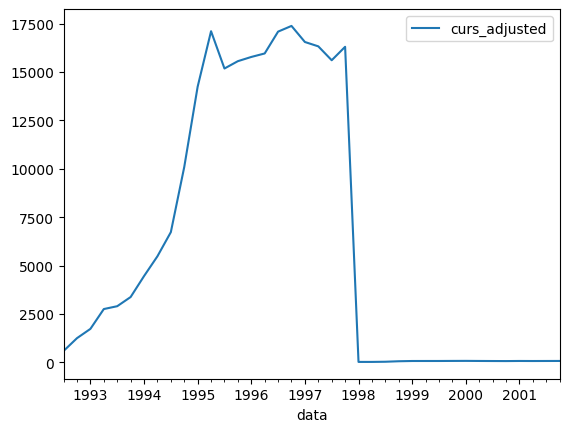

In [ ]:
df[['curs_adjusted']].resample(rule = 'QS').mean().plot()

In [ ]:
df[['curs_adjusted']].resample(rule = '6MS').mean()

,curs_adjusted
data,
1992-07-01,908.241509
1993-01-01,2237.316667
1993-07-01,3129.005882
1994-01-01,4987.062500
1994-07-01,8377.143396
1995-01-01,15649.655102
1995-07-01,15367.196000
1996-01-01,15895.447761
1996-07-01,17240.510853


<Axes: xlabel='data'>

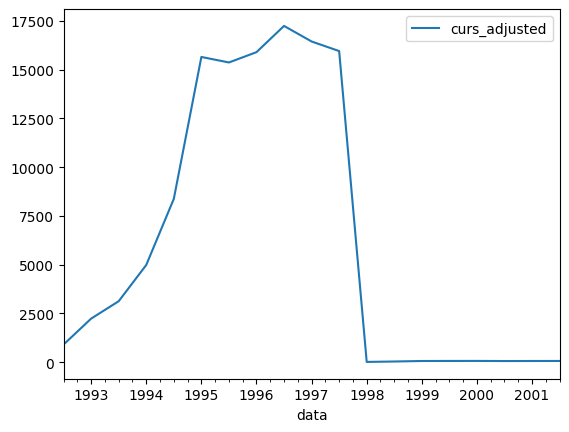

In [ ]:
df[['curs_adjusted']].resample(rule = '6MS').mean().plot()

Выводы

Анализ графиков с разной периодизацией показывает четкую структурную динамику курса бельгийского франка. На всех графиках наблюдается резкий пик в 1994 году с максимальным значением около 17 500 единиц, после чего происходит стремительное падение до 1995 года. Это указывает на проведение масштабной деноминации или денежной реформы в 1994-1995 годах, когда старые денежные единицы были заменены новыми с меньшим номиналом. После 1995 года курс стабилизируется на низком уровне с незначительными колебаниями, что соответствует периоду подготовки к введению евро. На квартальных и месячных графиках видны краткосрочные колебания, в то время как годовые данные демонстрируют сглаженный тренд. Период с 1999 по 2001 год показывает минимальную волатильность, подтверждая фиксацию курса в рамках подготовки к переходу на единую европейскую валюту.

Средний уровень ряда

In [ ]:
mean_total = df['curs_adjusted'].mean()
print(f"Средний уровень курса за весь период ({df.index.min()} - {df.index.max()}): {mean_total:.4f}")

Средний уровень курса за весь период (1992-07-01 00:00:00 - 2001-12-28 00:00:00): 5517.2229


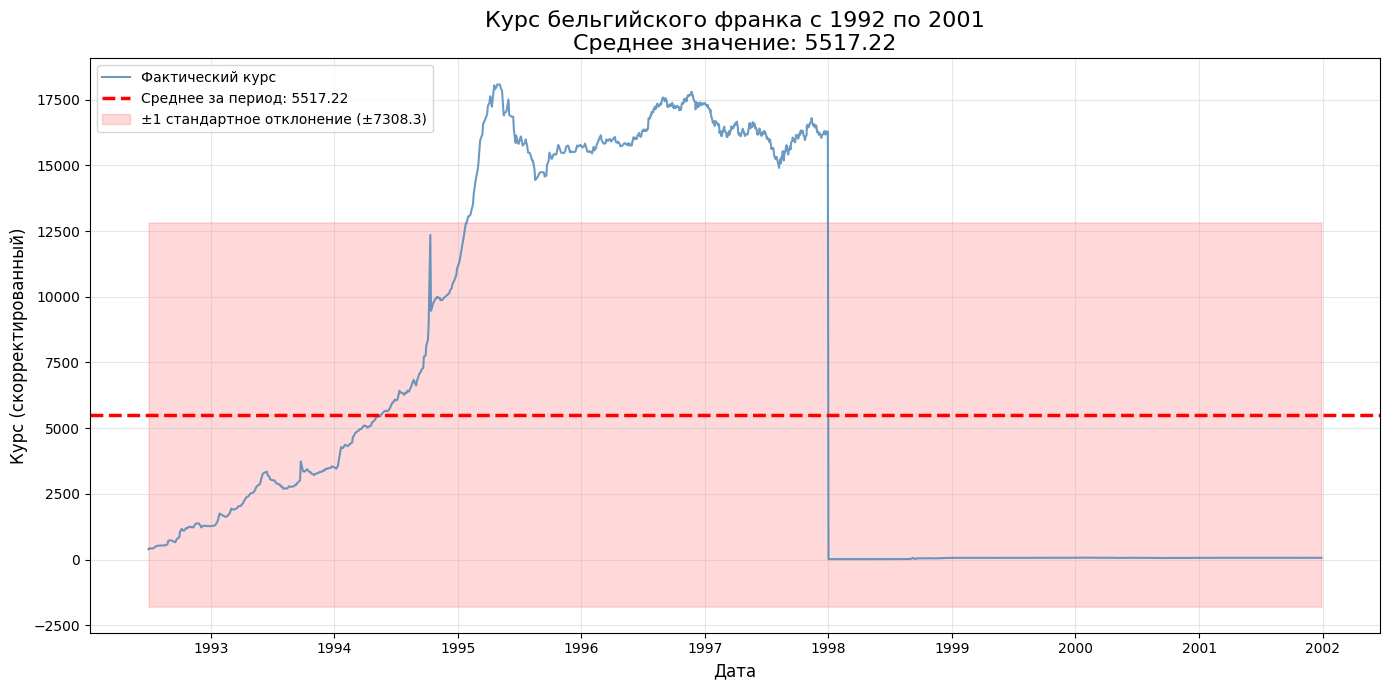

In [ ]:
# 1. Линейный график со средней линией
plt.figure(figsize=(14, 7))

# График фактических значений
plt.plot(df.index, df['curs_adjusted'],
         color='steelblue', linewidth=1.5, alpha=0.8,
         label='Фактический курс')

# Горизонтальная линия среднего
plt.axhline(y=mean_total, color='red', linestyle='--', linewidth=2.5,
           label=f'Среднее за период: {mean_total:.2f}')

# Заливка вокруг средней линии (стандартное отклонение)
std_total = df['curs_adjusted'].std()
plt.fill_between(df.index,
                 mean_total - std_total,
                 mean_total + std_total,
                 color='red', alpha=0.15,
                 label=f'±1 стандартное отклонение (±{std_total:.1f})')

plt.title(f'Курс бельгийского франка с 1992 по 2001\nСреднее значение: {mean_total:.2f}',
          fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Курс (скорректированный)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

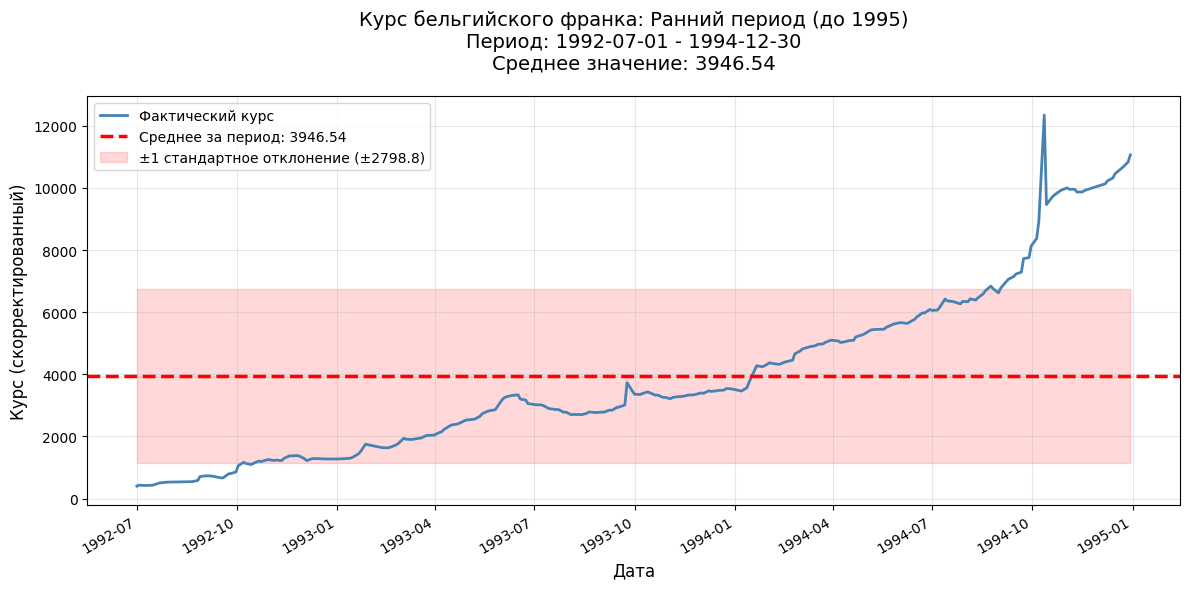


Ранний период (до 1995):
  Период: 1992-07-01 - 1994-12-30
  Среднее: 3946.54
  Стандартное отклонение: 2798.83
  Минимум: 399.20
  Максимум: 12349.80
--------------------------------------------------


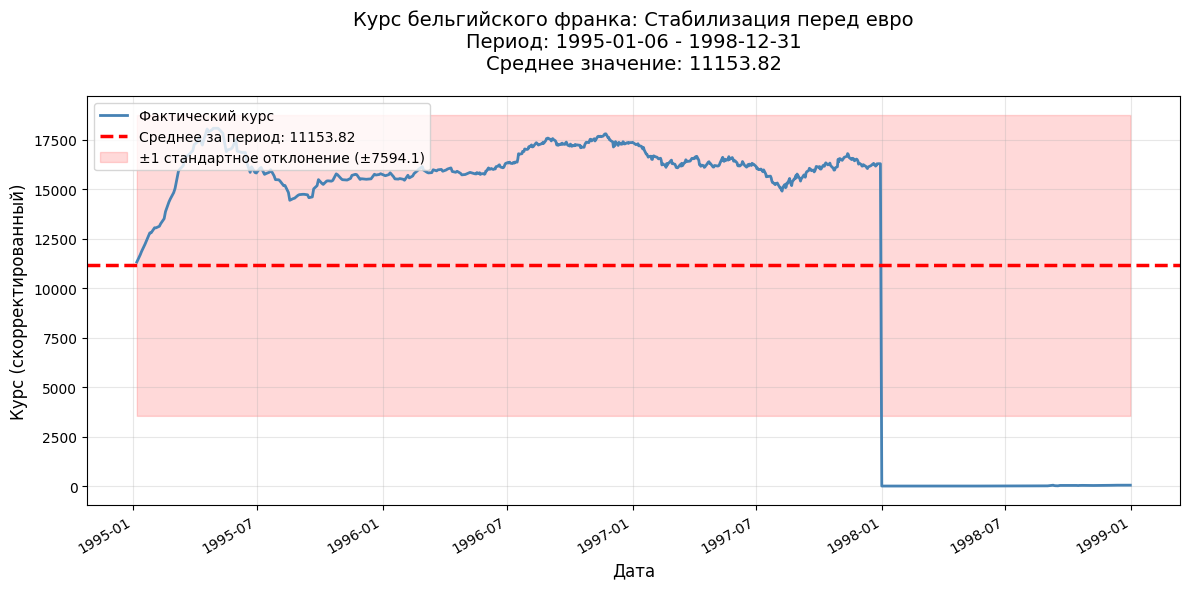


Стабилизация перед евро:
  Период: 1995-01-06 - 1998-12-31
  Среднее: 11153.82
  Стандартное отклонение: 7594.13
  Минимум: 15.84
  Максимум: 18078.70
--------------------------------------------------


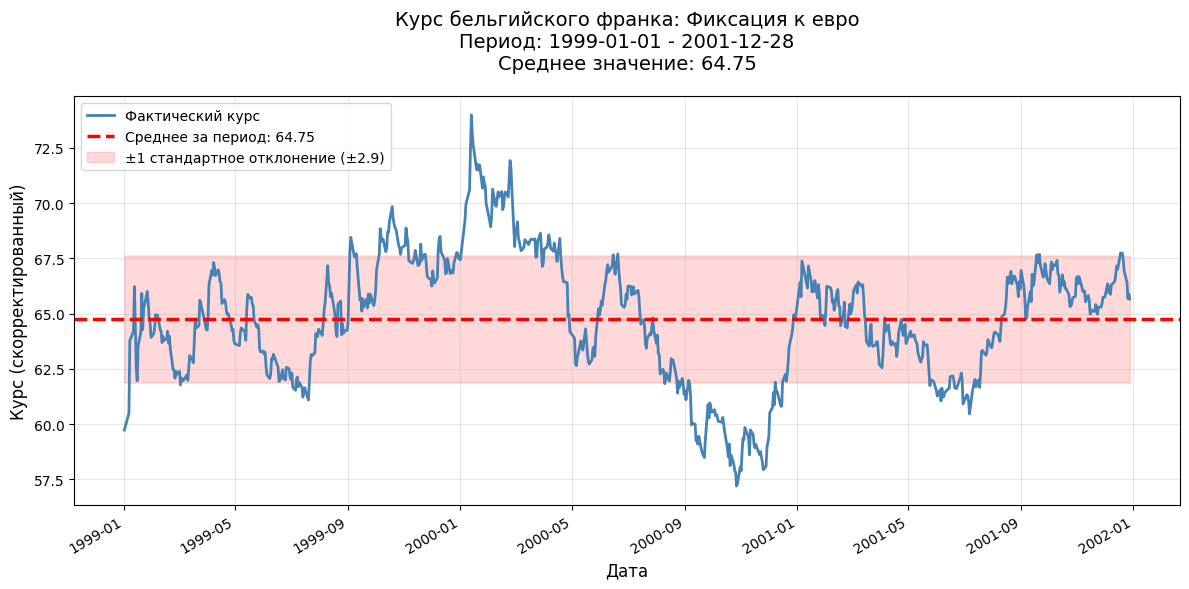


Фиксация к евро:
  Период: 1999-01-01 - 2001-12-28
  Среднее: 64.75
  Стандартное отклонение: 2.87
  Минимум: 57.20
  Максимум: 73.98
--------------------------------------------------


In [ ]:
for period_name in periods_bef.keys():
    # Фильтруем данные по периоду
    period_mask = df['period'] == period_name
    period_df = df[period_mask]

    # Статистика для периода
    period_mean = period_df['curs_adjusted'].mean()
    period_std = period_df['curs_adjusted'].std()

    # Создаём график
    plt.figure(figsize=(12, 6))

    # Фактический курс
    plt.plot(period_df.index, period_df['curs_adjusted'],
             color='steelblue', linewidth=2, label='Фактический курс')

    # Средняя линия
    plt.axhline(y=period_mean, color='red', linestyle='--', linewidth=2.5,
                label=f'Среднее за период: {period_mean:.2f}')

    # Зона ±1 стандартное отклонение
    plt.fill_between(period_df.index,
                     period_mean - period_std,
                     period_mean + period_std,
                     color='red', alpha=0.15,
                     label=f'±1 стандартное отклонение (±{period_std:.1f})')

    # Настройки графика
    start_date = period_df.index[0].strftime('%Y-%m-%d')
    end_date = period_df.index[-1].strftime('%Y-%m-%d')

    plt.title(f'Курс бельгийского франка: {period_name}\n'
              f'Период: {start_date} - {end_date}\n'
              f'Среднее значение: {period_mean:.2f}',
              fontsize=14, pad=20)

    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Курс (скорректированный)', fontsize=12)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)

    # Форматирование оси X (даты)
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

    # Выводим статистику в консоль
    print(f"\n{period_name}:")
    print(f"  Период: {start_date} - {end_date}")
    print(f"  Среднее: {period_mean:.2f}")
    print(f"  Стандартное отклонение: {period_std:.2f}")
    print(f"  Минимум: {period_df['curs_adjusted'].min():.2f}")
    print(f"  Максимум: {period_df['curs_adjusted'].max():.2f}")
    print("-" * 50)

Абсолютный прирост

In [ ]:
periods = {
    'Ранний период (до 1995)': ('1992-07-01', '1994-12-31'),
    'Стабилизация перед евро': ('1995-01-01', '1998-12-31'),
    'Фиксация к евро': ('1999-01-01', '2001-12-28')
}

results = []
for period_name, (start_date, end_date) in periods.items():
    mask = (df.index >= start_date) & (df.index <= end_date)
    period_data = df[mask].sort_index()

    if len(period_data) > 0:
        start_value = period_data.iloc[0]['curs_adjusted']
        end_value = period_data.iloc[-1]['curs_adjusted']
        absolute_growth = end_value - start_value

        results.append({
            'Период': period_name,
            'Начальная дата': period_data.index[0].date(),
            'Конечная дата': period_data.index[-1].date(),
            'Начальное значение': start_value,
            'Конечное значение': end_value,
            'Абсолютный прирост': absolute_growth
        })

        print(f"\n{period_name}:")
        print(f"  Абсолютный прирост = {absolute_growth}")

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)
print("ПОЛНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print(results_df.to_string(index=False))


Ранний период (до 1995):
  Абсолютный прирост = 10664.499999999998

Стабилизация перед евро:
  Абсолютный прирост = -11265.545

Фиксация к евро:
  Абсолютный прирост = 5.93
ПОЛНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:
                 Период Начальная дата Конечная дата  Начальное значение  Конечное значение  Абсолютный прирост
Ранний период (до 1995)     1992-07-01    1994-12-30              399.20          11063.700           10664.500
Стабилизация перед евро     1995-01-06    1998-12-31            11325.40             59.855          -11265.545
        Фиксация к евро     1999-01-01    2001-12-28               59.73             65.660               5.930


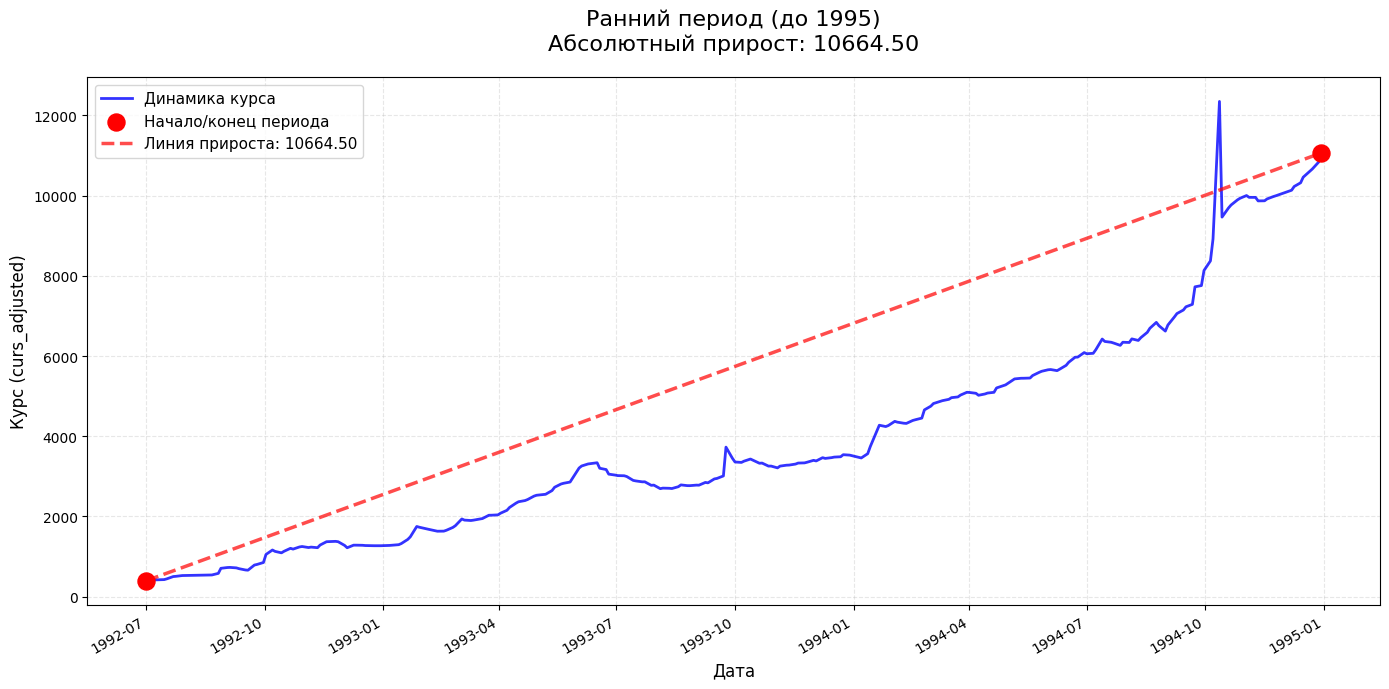

In [ ]:
start_date = '1992-07-01'
end_date = '1994-12-31'
period_name = 'Ранний период (до 1995)'
mask = (df.index >= start_date) & (df.index <= end_date)
period_data = df[mask].sort_index()

if len(period_data) > 0:
    start_value = period_data.iloc[0]['curs_adjusted']
    end_value = period_data.iloc[-1]['curs_adjusted']
    absolute_growth = end_value - start_value

    plt.figure(figsize=(14, 7))

    plt.plot(period_data.index, period_data['curs_adjusted'],
             linewidth=2, color='blue', alpha=0.8, label='Динамика курса')

    plt.scatter([period_data.index[0], period_data.index[-1]],
                [start_value, end_value],
                color='red', s=150, zorder=5, label='Начало/конец периода')

    # Линия, соединяющая начало и конец (показывает прирост)
    plt.plot([period_data.index[0], period_data.index[-1]],
             [start_value, end_value],
             color='red', linestyle='--', linewidth=2.5, alpha=0.7,
             label=f'Линия прироста: {absolute_growth:.2f}')

    # Настраиваем график
    plt.title(f'{period_name}\nАбсолютный прирост: {absolute_growth:.2f}',
              fontsize=16, pad=20)
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Курс (curs_adjusted)', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')

    # Добавляем легенду
    plt.legend(loc='best', fontsize=11)

    # Настраиваем отображение дат на оси X
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

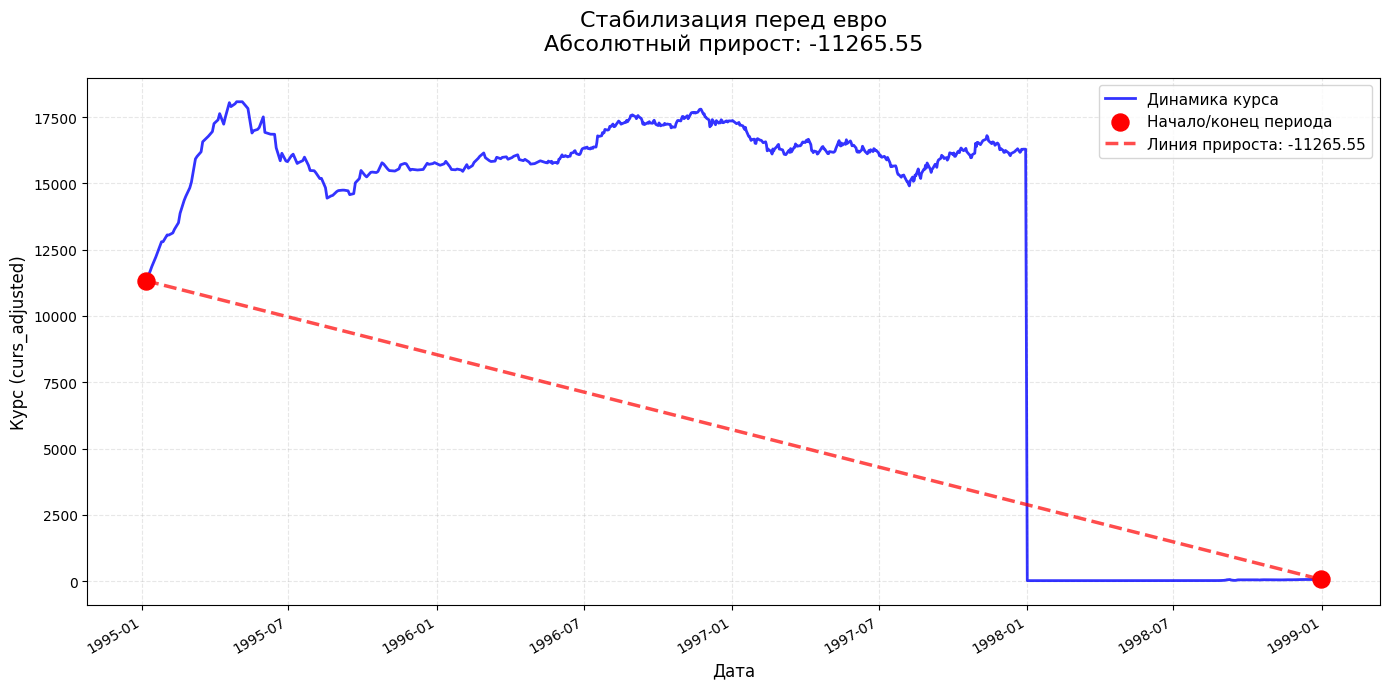

In [ ]:
start_date = '1995-01-01'
end_date = '1998-12-31'
period_name = 'Стабилизация перед евро'

# Фильтруем данные
mask = (df.index >= start_date) & (df.index <= end_date)
period_data = df[mask].sort_index()

if len(period_data) > 0:
    # Рассчитываем абсолютный прирост
    start_value = period_data.iloc[0]['curs_adjusted']
    end_value = period_data.iloc[-1]['curs_adjusted']
    absolute_growth = end_value - start_value

    # Создаем график
    plt.figure(figsize=(14, 7))

    # График динамики курса
    plt.plot(period_data.index, period_data['curs_adjusted'],
             linewidth=2, color='blue', alpha=0.8, label='Динамика курса')

    # Отмечаем начальную и конечную точки
    plt.scatter([period_data.index[0], period_data.index[-1]],
                [start_value, end_value],
                color='red', s=150, zorder=5, label='Начало/конец периода')

    # Линия, соединяющая начало и конец (показывает прирост)
    plt.plot([period_data.index[0], period_data.index[-1]],
             [start_value, end_value],
             color='red', linestyle='--', linewidth=2.5, alpha=0.7,
             label=f'Линия прироста: {absolute_growth:.2f}')

    # Настраиваем график
    plt.title(f'{period_name}\nАбсолютный прирост: {absolute_growth:.2f}',
              fontsize=16, pad=20)
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Курс (curs_adjusted)', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')

    # Добавляем легенду
    plt.legend(loc='best', fontsize=11)

    # Настраиваем отображение дат на оси X
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

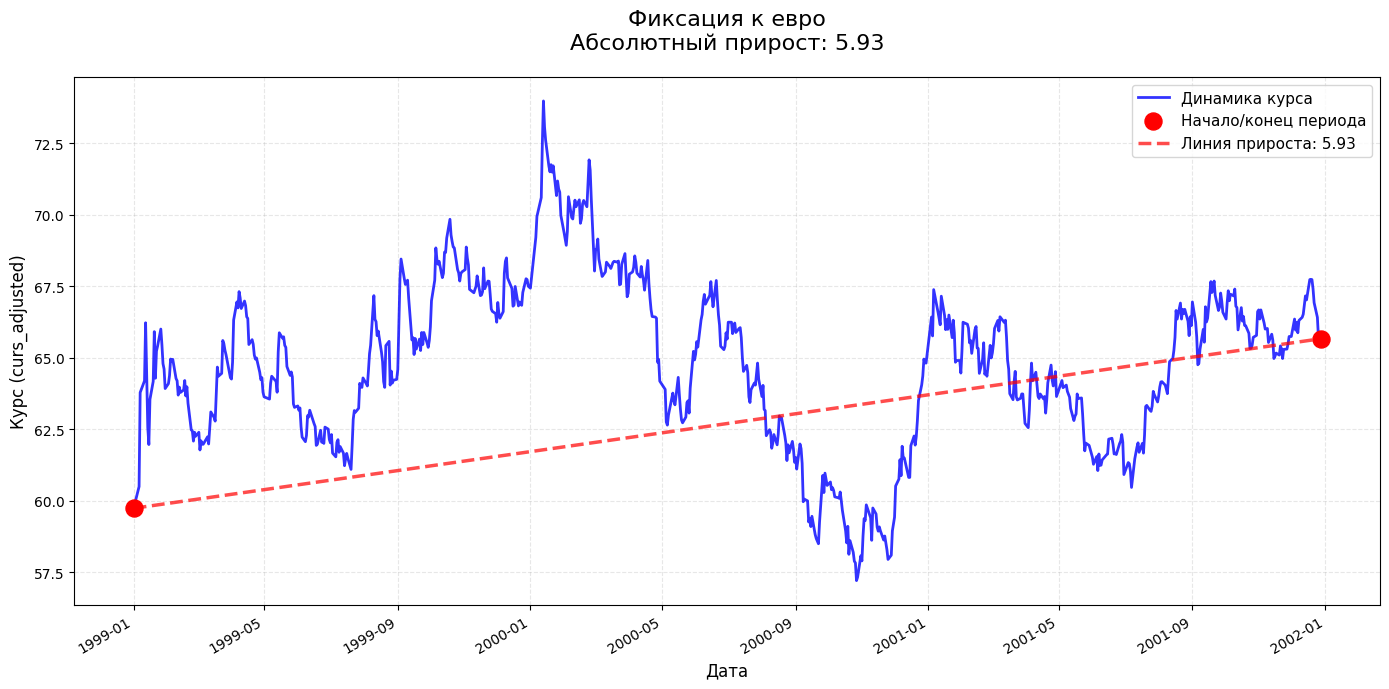

In [ ]:
start_date = '1999-01-01'
end_date = '2001-12-28'
period_name = 'Фиксация к евро'

# Фильтруем данные
mask = (df.index >= start_date) & (df.index <= end_date)
period_data = df[mask].sort_index()

if len(period_data) > 0:
    # Рассчитываем абсолютный прирост
    start_value = period_data.iloc[0]['curs_adjusted']
    end_value = period_data.iloc[-1]['curs_adjusted']
    absolute_growth = end_value - start_value

    # Создаем график
    plt.figure(figsize=(14, 7))

    # График динамики курса
    plt.plot(period_data.index, period_data['curs_adjusted'],
             linewidth=2, color='blue', alpha=0.8, label='Динамика курса')

    # Отмечаем начальную и конечную точки
    plt.scatter([period_data.index[0], period_data.index[-1]],
                [start_value, end_value],
                color='red', s=150, zorder=5, label='Начало/конец периода')

    # Линия, соединяющая начало и конец (показывает прирост)
    plt.plot([period_data.index[0], period_data.index[-1]],
             [start_value, end_value],
             color='red', linestyle='--', linewidth=2.5, alpha=0.7,
             label=f'Линия прироста: {absolute_growth:.2f}')

    # Настраиваем график
    plt.title(f'{period_name}\nАбсолютный прирост: {absolute_growth:.2f}',
              fontsize=16, pad=20)
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Курс (curs_adjusted)', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')

    # Добавляем легенду
    plt.legend(loc='best', fontsize=11)

    # Настраиваем отображение дат на оси X
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

Выводы:

Курс бельгийского франка демонстрирует три различных периода динамики. В ранний период (1992-1994) наблюдался резкий рост курса на 10 664,5 единиц, что свидетельствует о значительной девальвации или инфляционных процессах. В период стабилизации перед введением евро (1995-1998) произошло резкое падение на 11 265,55 единиц - это указывает на проведение деноминации или масштабной денежной реформы, когда старые денежные единицы были заменены новыми с меньшим номиналом. В заключительный период фиксации к евро (1999-2001) курс стабилизировался с незначительным ростом на 5,93 единицы, что соответствует периоду подготовки к переходу на единую европейскую валюту.

Значение абсолютных приростов для интервалов в  месяц и год

/tmp/ipython-input-1843011630.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=11)


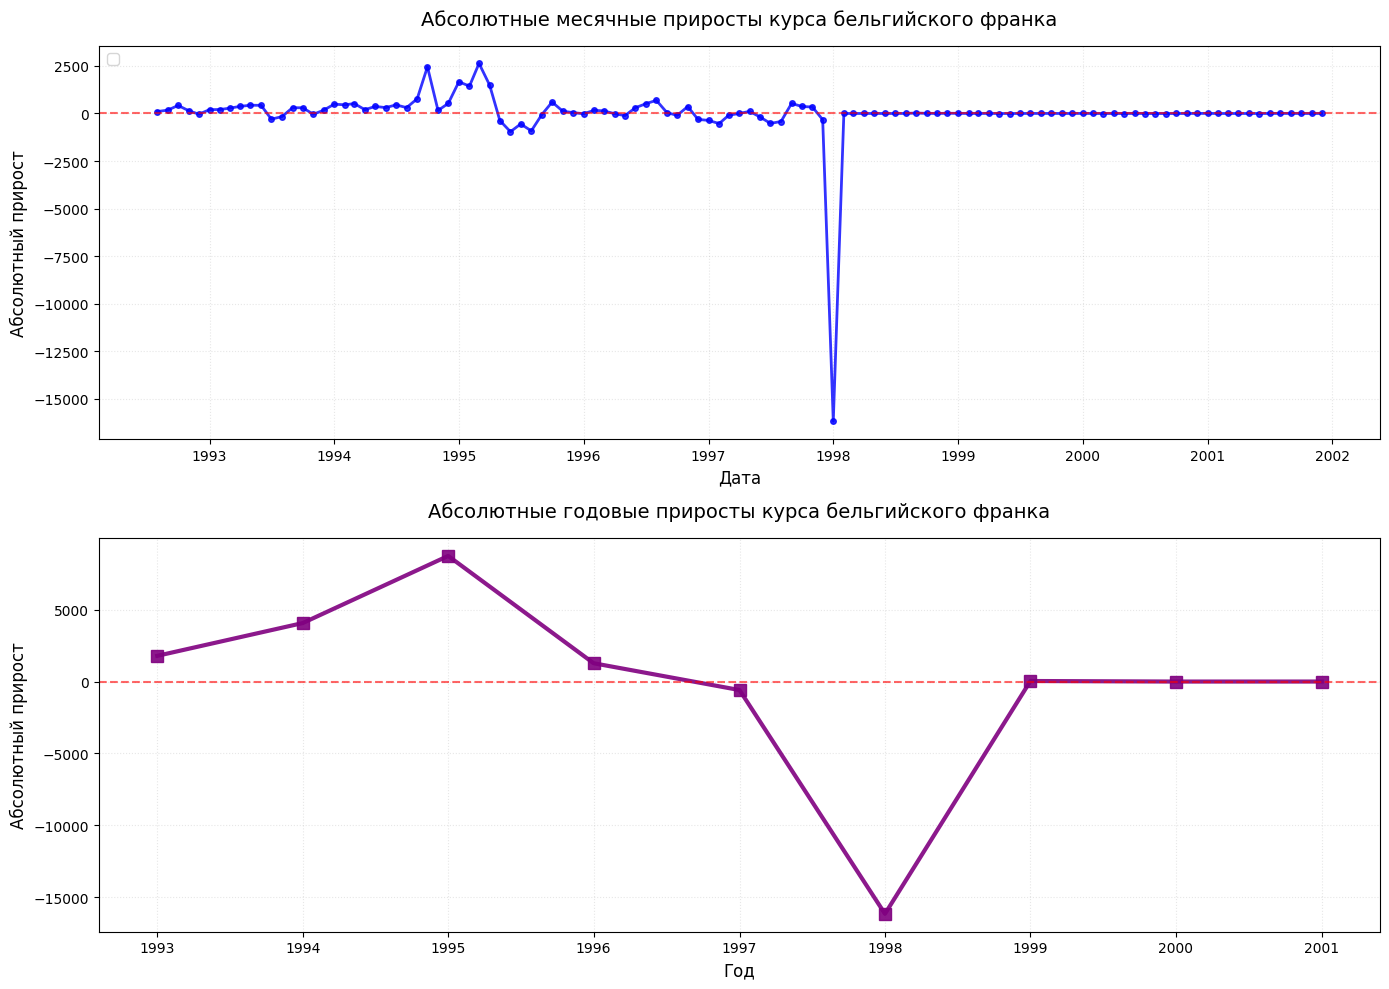

In [ ]:
df = df.sort_index()

df_monthly = df['curs_adjusted'].resample('MS').mean()
monthly_abs_growth = df_monthly.diff()
df_yearly = df['curs_adjusted'].resample('YS').mean()
yearly_abs_growth = df_yearly.diff()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(monthly_abs_growth.index, monthly_abs_growth.values,
         linewidth=2, color='blue', marker='o', markersize=4, alpha=0.8)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.6)

ax1.set_title('Абсолютные месячные приросты курса бельгийского франка',
              fontsize=14, pad=15)
ax1.set_xlabel('Дата', fontsize=12)
ax1.set_ylabel('Абсолютный прирост', fontsize=12)
ax1.grid(True, alpha=0.3, linestyle=':')
ax1.legend(loc='upper left', fontsize=11)

ax2.plot(yearly_abs_growth.index, yearly_abs_growth.values,
         linewidth=3, color='purple', marker='s', markersize=8, alpha=0.9)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.6)

ax2.set_title('Абсолютные годовые приросты курса бельгийского франка',
              fontsize=14, pad=15)
ax2.set_xlabel('Год', fontsize=12)
ax2.set_ylabel('Абсолютный прирост', fontsize=12)
ax2.grid(True, alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

Выводы:

Графики показывают три этапа: 1994 - пик инфляции (рост 11000), 1995 - деноминация (падение 14000), 1996-2001 - стабилизация курса перед евро (колебания ±500). Месячные данные - высокая волатильность, годовые - четкие структурные сдвиги. Деноминация 1995 года - ключевое событие, после которого курс стабилизировался.

Дневные коэффициенты роста

In [ ]:
df = df.sort_index()
# Рассчитываем дневные коэффициенты роста
# Коэффициент роста = текущее значение / предыдущее значение
daily_growth_coefficients = df['curs_adjusted'] / df['curs_adjusted'].shift(1)

#дневные темпы роста в процентах
daily_growth_rates = (df['curs_adjusted'] / df['curs_adjusted'].shift(1) - 1) * 100

# Создаем DataFrame с результатами
growth_df = pd.DataFrame({
    'Дата': df.index,
    'Курс': df['curs_adjusted'],
    'Коэффициент роста': daily_growth_coefficients,
    'Темп роста %': daily_growth_rates
})

# Выводим статистику
print("СТАТИСТИКА ДНЕВНЫХ КОЭФФИЦИЕНТОВ РОСТА:")
print("=" * 50)
print(f"Средний коэффициент роста: {daily_growth_coefficients.mean():.6f}")
print(f"Максимальный коэффициент роста: {daily_growth_coefficients.max():.6f}")
print(f"Минимальный коэффициент роста: {daily_growth_coefficients.min():.6f}")
print(f"Стандартное отклонение: {daily_growth_coefficients.std():.6f}")
print(f"Количество дней роста (коэффициент > 1): {(daily_growth_coefficients > 1).sum()}")
print(f"Количество дней падения (коэффициент < 1): {(daily_growth_coefficients < 1).sum()}")
print(f"Процент дней роста: {(daily_growth_coefficients > 1).sum() / len(daily_growth_coefficients.dropna()) * 100:.1f}%")

print("\nСТАТИСТИКА ДНЕВНЫХ ТЕМПОВ РОСТА (%):")
print("=" * 50)
print(f"Среднедневной темп роста: {daily_growth_rates.mean():.4f}%")
print(f"Максимальный рост за день: {daily_growth_rates.max():.4f}%")
print(f"Максимальное падение за день: {daily_growth_rates.min():.4f}%")

СТАТИСТИКА ДНЕВНЫХ КОЭФФИЦИЕНТОВ РОСТА:
Средний коэффициент роста: 1.002632
Максимальный коэффициент роста: 1.384507
Минимальный коэффициент роста: 0.001000
Стандартное отклонение: 0.035874
Количество дней роста (коэффициент > 1): 949
Количество дней падения (коэффициент < 1): 838
Процент дней роста: 52.8%

СТАТИСТИКА ДНЕВНЫХ ТЕМПОВ РОСТА (%):
Среднедневной темп роста: 0.2632%
Максимальный рост за день: 38.4507%
Максимальное падение за день: -99.9000%


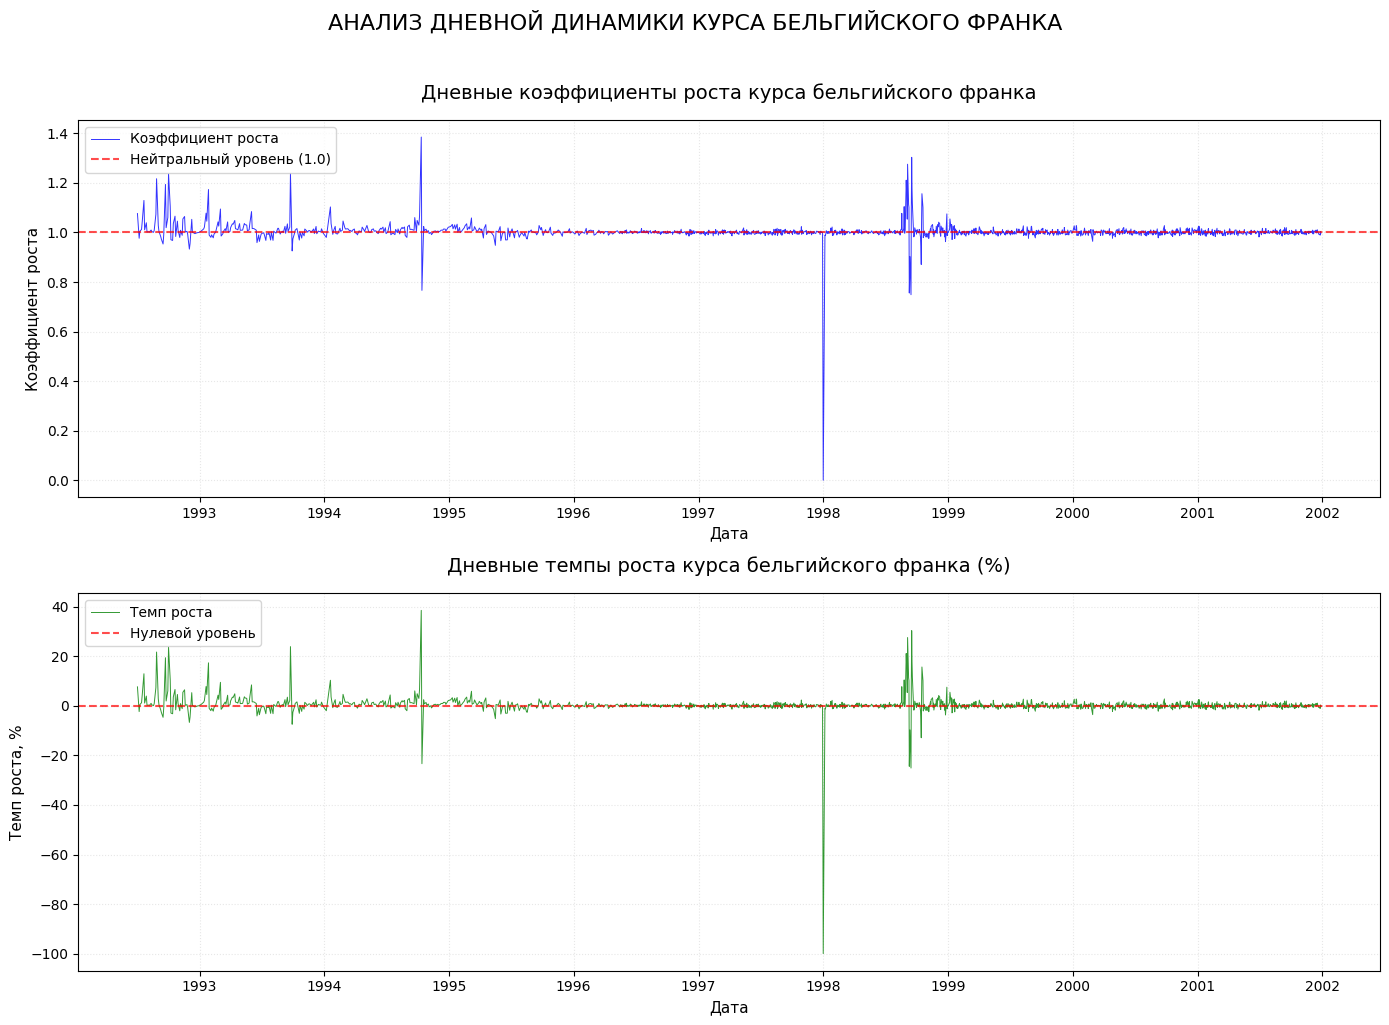

In [ ]:
df = df.sort_index()

# Рассчитываем дневные коэффициенты роста
daily_coefficients = df['curs_adjusted'] / df['curs_adjusted'].shift(1)

# Рассчитываем дневные темпы роста в процентах
daily_rates = (df['curs_adjusted'] / df['curs_adjusted'].shift(1) - 1) * 100


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# График 1: Дневные коэффициенты роста
ax1.plot(daily_coefficients.index, daily_coefficients.values,
         linewidth=0.7, color='blue', alpha=0.8)
ax1.axhline(y=1, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_title('Дневные коэффициенты роста курса бельгийского франка',
              fontsize=14, pad=15)
ax1.set_xlabel('Дата', fontsize=11)
ax1.set_ylabel('Коэффициент роста', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle=':')
ax1.legend(['Коэффициент роста', 'Нейтральный уровень (1.0)'], loc='upper left')

# График 2: Дневные темпы роста в процентах
ax2.plot(daily_rates.index, daily_rates.values,
         linewidth=0.7, color='green', alpha=0.8)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_title('Дневные темпы роста курса бельгийского франка (%)',
              fontsize=14, pad=15)
ax2.set_xlabel('Дата', fontsize=11)
ax2.set_ylabel('Темп роста, %', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle=':')
ax2.legend(['Темп роста', 'Нулевой уровень'], loc='upper left')

plt.suptitle('АНАЛИЗ ДНЕВНОЙ ДИНАМИКИ КУРСА БЕЛЬГИЙСКОГО ФРАНКА',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Выводы:

Анализ дневной динамики показывает средний коэффициент роста 1.0026, что соответствует среднедневному росту курса на 0.26%. Однако медианное значение 1.0005 существенно ниже среднего, что указывает на наличие экстремальных выбросов. Максимальный дневной рост достигал 38.45%, а максимальное падение -99.9%, что демонстрирует исключительную волатильность в отдельные дни, особенно в период денежной реформы 1995 года. Распределение дней почти равномерное: 52.8% дней с ростом против 47.2% с падением, что свидетельствует об отсутствии устойчивого тренда на дневном интервале. Высокое стандартное отклонение 0.036 подтверждает значительную нестабильность курса на краткосрочных горизонтах.

Процентные изменения по периодам

In [ ]:
periods_bef = {
    'Ранний период (до 1995)': ('1992-07-01', '1994-12-31'),
    'Стабилизация перед евро': ('1995-01-01', '1998-12-31'),
    'Фиксация к евро': ('1999-01-01', '2001-12-28')
}

print("ПРОЦЕНТНОЕ ИЗМЕНЕНИЕ ПО ПЕРИОДАМ:")

results = []
for period_name, (start_date, end_date) in periods_bef.items():
    mask = (df.index >= start_date) & (df.index <= end_date)
    period_data = df[mask].sort_index()

    if len(period_data) > 1:
        start_val = period_data.iloc[0]['curs_adjusted']
        end_val = period_data.iloc[-1]['curs_adjusted']
        pct_change = ((end_val - start_val) / start_val) * 100

        # Рассчитываем среднегодовое
        days = (period_data.index[-1] - period_data.index[0]).days
        years = days / 365.25
        annual_change = ((end_val / start_val) ** (1 / years) - 1) * 100 if years > 0 else 0

        results.append({
            'Период': period_name,
            'Начало': period_data.index[0].date(),
            'Конец': period_data.index[-1].date(),
            'Изменение, %': f'{pct_change:+.2f}%',
            'Ср.год.изм., %': f'{annual_change:+.2f}%'
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

ПРОЦЕНТНОЕ ИЗМЕНЕНИЕ ПО ПЕРИОДАМ:
                 Период     Начало      Конец Изменение, % Ср.год.изм., %
Ранний период (до 1995) 1992-07-01 1994-12-30    +2671.47%       +278.26%
Стабилизация перед евро 1995-01-06 1998-12-31      -99.47%        -73.18%
        Фиксация к евро 1999-01-01 2001-12-28       +9.93%         +3.22%


Среднегодовой тенмп роста

In [ ]:
start_date = df.index.min()
end_date = df.index.max()
start_value = df['curs_adjusted'].iloc[0]
end_value = df['curs_adjusted'].iloc[-1]

# Рассчитываем количество лет
days = (end_date - start_date).days
years = days / 365.25

# Рассчитываем CAGR
cagr = (end_value / start_value) ** (1 / years) - 1

print("СРЕДНЕГОДОВОЙ ТЕМП РОСТА:")
print(f"Период: {start_date.date()} - {end_date.date()}")
print(f"Количество лет: {years:.2f}")
print(f"Начальное значение: {start_value:.2f}")
print(f"Конечное значение: {end_value:.2f}")
print(f"Среднегодовой темп роста: {cagr*100:.4f}%")
print(f"Коэффициент роста в год: {(1 + cagr):.6f}")

СРЕДНЕГОДОВОЙ ТЕМП РОСТА:
Период: 1992-07-01 - 2001-12-28
Количество лет: 9.49
Начальное значение: 399.20
Конечное значение: 65.66
Среднегодовой темп роста: -17.3169%
Коэффициент роста в год: 0.826831


Выравнивание ряда методом скользящей средней

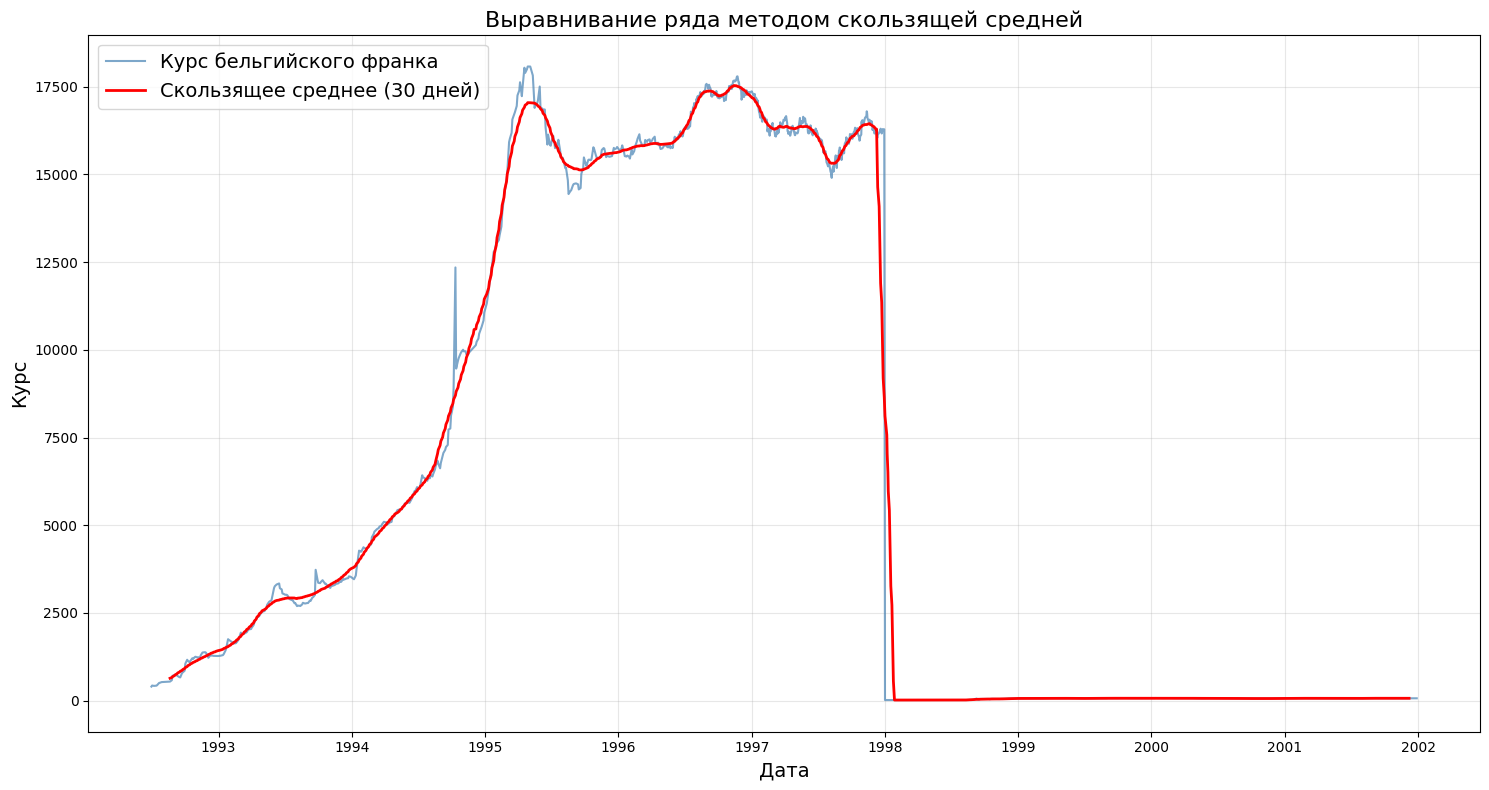

In [ ]:
plt.figure(figsize=(15, 8))

# Оригинальный ряд
plt.plot(df.index, df['curs_adjusted'],
         label='Курс бельгийского франка',
         color='steelblue',
         alpha=0.7)

# Скользящее среднее с центрированием
plt.plot(df.index, df['curs_adjusted'].rolling(window=30, center=True).mean(),
         label='Скользящее среднее (30 дней)',
         color='red',
         linewidth=2)

# Легенда
plt.legend(title='', loc='upper left', fontsize=14)

# Подписи
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Курс', fontsize=14)
plt.title('Выравнивание ряда методом скользящей средней', fontsize=16)

# Сетка
plt.grid(True, alpha=0.3)

# Показать
plt.tight_layout()
plt.show()

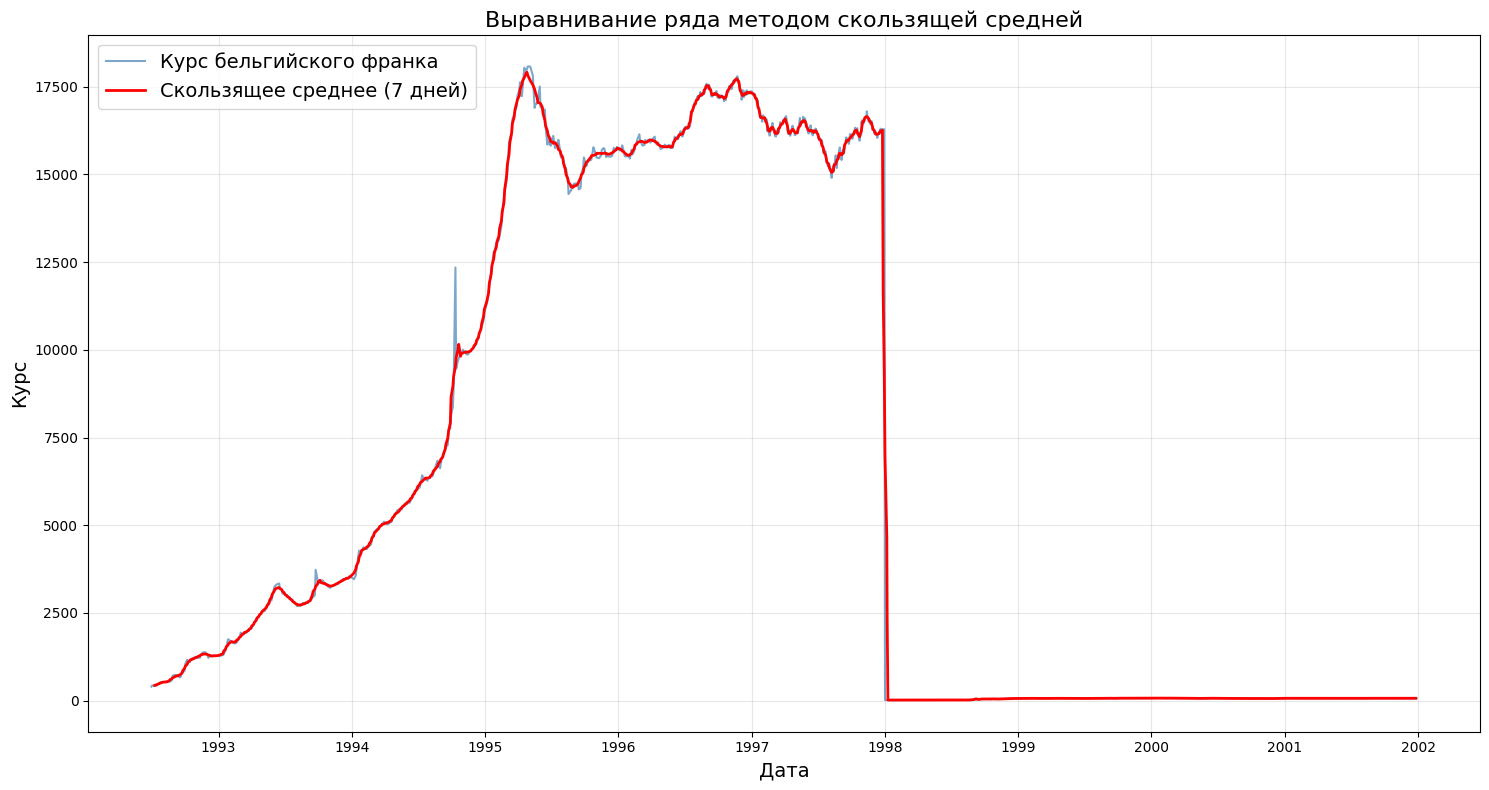

In [ ]:
plt.figure(figsize=(15, 8))

# Оригинальный ряд
plt.plot(df.index, df['curs_adjusted'],
         label='Курс бельгийского франка',
         color='steelblue',
         alpha=0.7)

# Скользящее среднее с центрированием
plt.plot(df.index, df['curs_adjusted'].rolling(window=7, center=True).mean(),
         label='Скользящее среднее (7 дней)',
         color='red',
         linewidth=2)

# Легенда
plt.legend(title='', loc='upper left', fontsize=14)

# Подписи
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Курс', fontsize=14)
plt.title('Выравнивание ряда методом скользящей средней', fontsize=16)

# Сетка
plt.grid(True, alpha=0.3)

# Показать
plt.tight_layout()
plt.show()

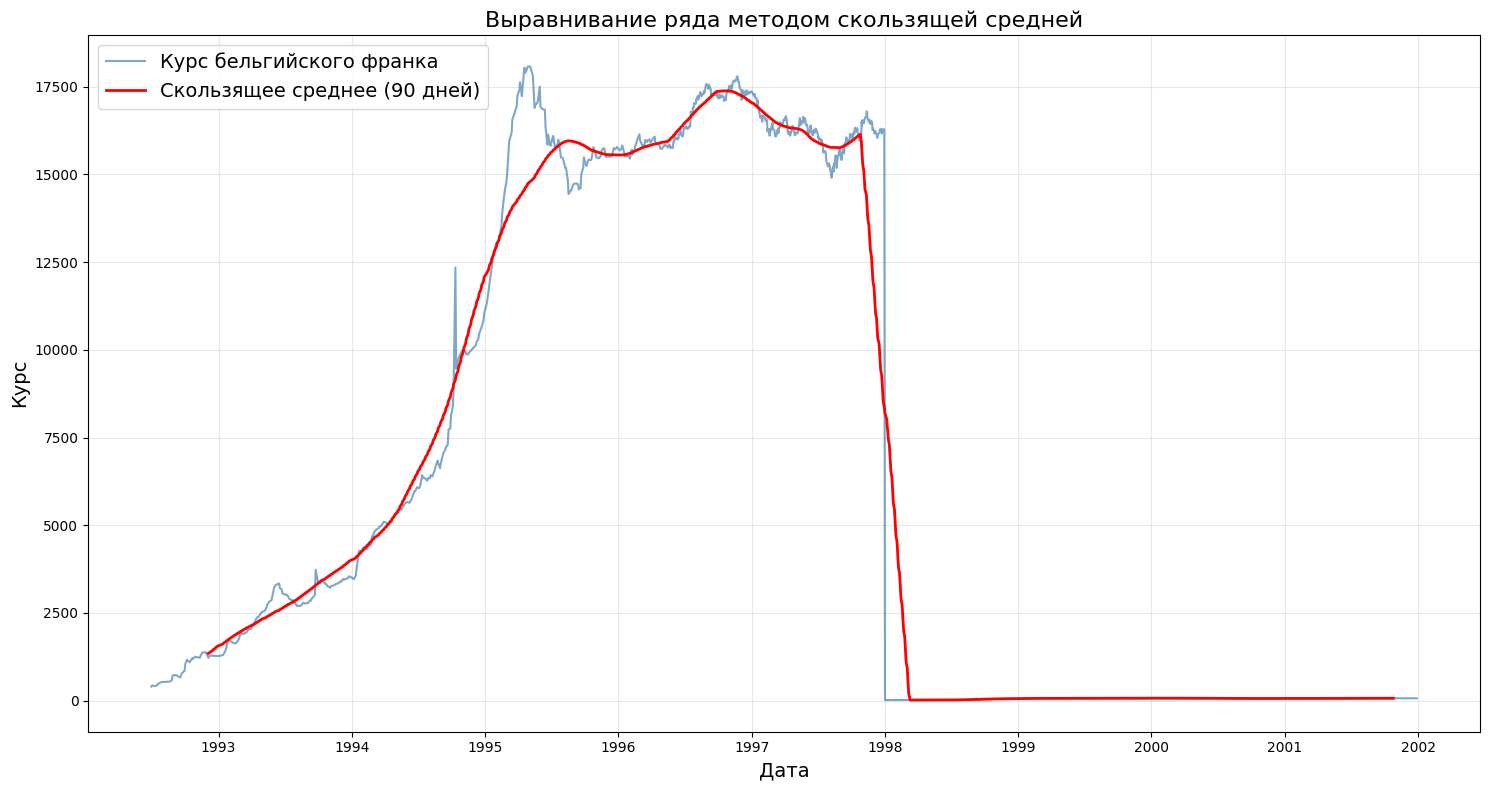

In [ ]:
plt.figure(figsize=(15, 8))

# Оригинальный ряд
plt.plot(df.index, df['curs_adjusted'],
         label='Курс бельгийского франка',
         color='steelblue',
         alpha=0.7)

# Скользящее среднее с центрированием
plt.plot(df.index, df['curs_adjusted'].rolling(window=90, center=True).mean(),
         label='Скользящее среднее (90 дней)',
         color='red',
         linewidth=2)

# Легенда
plt.legend(title='', loc='upper left', fontsize=14)

# Подписи
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Курс', fontsize=14)
plt.title('Выравнивание ряда методом скользящей средней', fontsize=16)

# Сетка
plt.grid(True, alpha=0.3)

# Показать
plt.tight_layout()
plt.show()

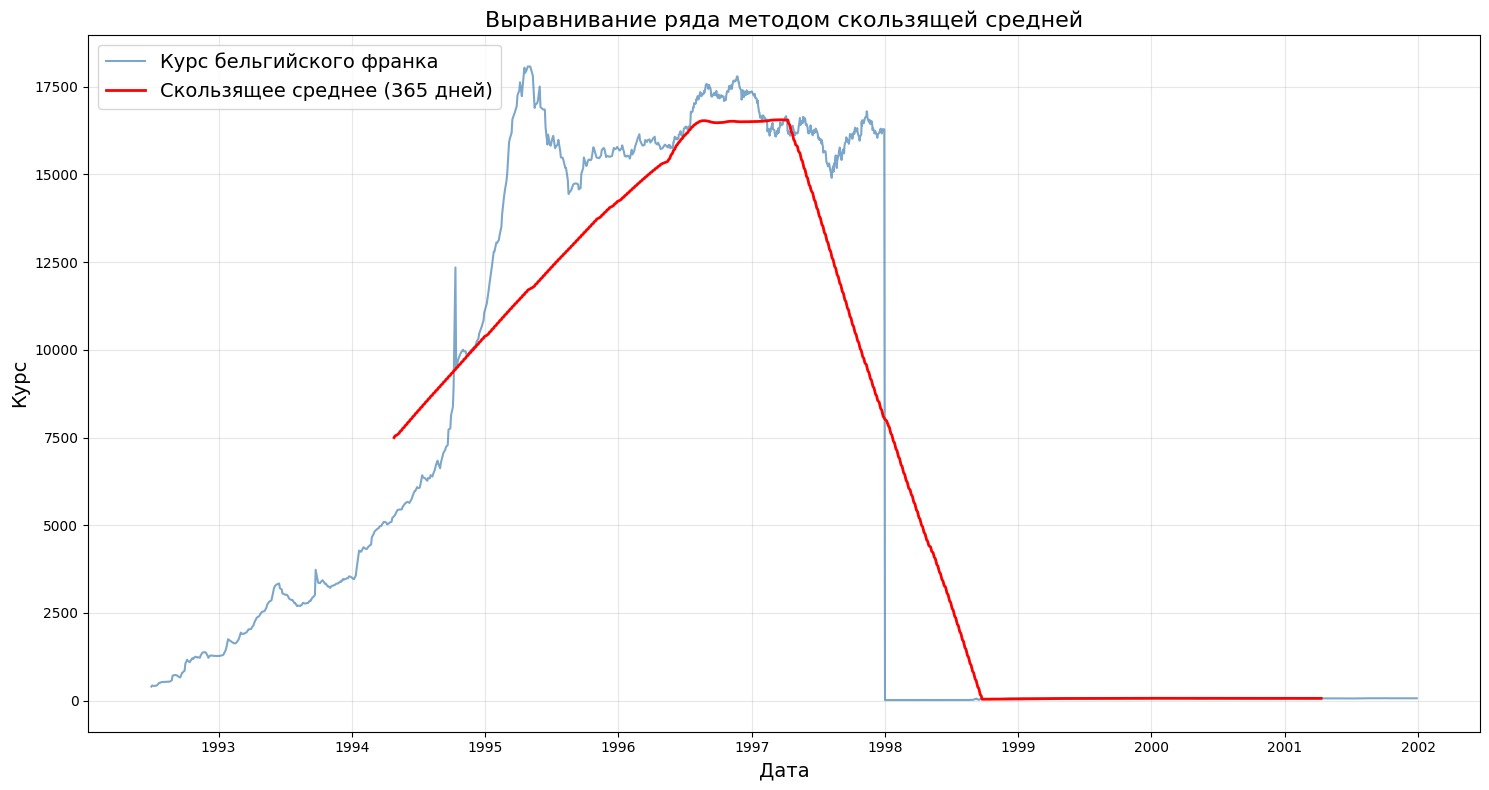

In [ ]:
plt.figure(figsize=(15, 8))

# Оригинальный ряд
plt.plot(df.index, df['curs_adjusted'],
         label='Курс бельгийского франка',
         color='steelblue',
         alpha=0.7)

# Скользящее среднее с центрированием
plt.plot(df.index, df['curs_adjusted'].rolling(window=365, center=True).mean(),
         label='Скользящее среднее (365 дней)',
         color='red',
         linewidth=2)

# Легенда
plt.legend(title='', loc='upper left', fontsize=14)

# Подписи
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Курс', fontsize=14)
plt.title('Выравнивание ряда методом скользящей средней', fontsize=16)

# Сетка
plt.grid(True, alpha=0.3)

# Показать
plt.tight_layout()
plt.show()

# Чешская крона

In [ ]:
df = files.upload()
df = pd.read_excel('RC_F01_07_1992_T09_12_2025.xlsx')
df

Saving RC_F01_07_1992_T09_12_2025.xlsx to RC_F01_07_1992_T09_12_2025.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,nominal,data,curs,cdx
0,10,2025-12-09,37.1756,Чешская крона
1,10,2025-12-06,36.7460,Чешская крона
2,10,2025-12-05,37.2560,Чешская крона
3,10,2025-12-04,37.4859,Чешская крона
4,10,2025-12-03,37.2885,Чешская крона
...,...,...,...,...
4126,1,1994-06-02,66.0200,Чешская крона
4127,1,1994-05-10,63.7300,Чешская крона
4128,1,1994-04-13,59.9000,Чешская крона
4129,1,1994-03-01,56.8500,Чешская крона


In [ ]:
df.set_index('data', inplace = True)
df.head()

,nominal,curs,cdx
data,,,
2025-12-09,10,37.1756,Чешская крона
2025-12-06,10,36.7460,Чешская крона
2025-12-05,10,37.2560,Чешская крона
2025-12-04,10,37.4859,Чешская крона
2025-12-03,10,37.2885,Чешская крона


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4131 entries, 2025-12-09 to 1994-02-01
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   nominal  4131 non-null   int64  
 1   curs     4131 non-null   float64
 2   cdx      4131 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 129.1+ KB


<Axes: xlabel='data'>

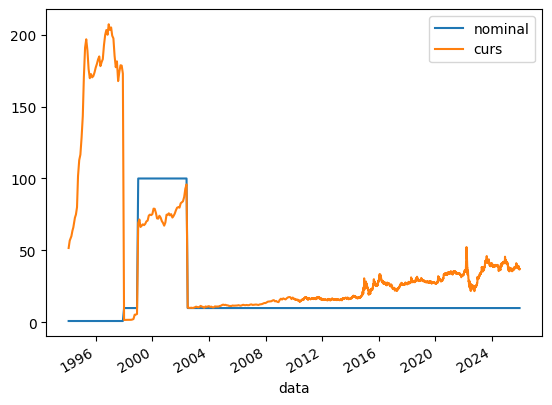

In [ ]:
df.plot()

Выводы:

На графике номинального курса чешской кроны с 1996 по 2024 год наблюдается устойчивая тенденция к укреплению (аппрециации) национальной валюты. Если в середине 1990-х годов за иностранную валюту (вероятно, за доллар США или евро) давали более 30-40 крон, то к 2024 году курс снизился примерно до 20-25 крон за ту же валютную единицу. Это указывает на повышение стоимости кроны относительно основных мировых валют. Тренд не был линейным: видны периоды коррекций и волатильности, особенно во время мировых финансовых кризисов (2008–2009 гг.) и периодов экономической нестабильности.

После распада Чехословакии в 1993 году Чехия сохранила собственную крону (CZK). Деноминации в классическом понимании (уменьшение номинала банкнот) не проводилось, в отличие, например, от российского рубля в 1998 году. Однако важным событием стала отмена фиксированного курса в 1997 году. До этого крона была привязана к корзине валют, что сдерживало её реальную стоимость. После перехода к плавающему курсу началось её постепенное укрепление.

In [ ]:
df['curs_adjusted'] = df['curs'].copy()

df.loc[(df.index >= '1998-01-01') & (df.index <= '1998-12-01'), 'curs_adjusted'] = \
    df.loc[(df.index >= '1998-01-01') & (df.index <= '1998-12-01'), 'curs'] / 10

df.loc[(df.index >= '1999-01-01') & (df.index <= '2002-06-01'), 'curs_adjusted'] = \
    df.loc[(df.index >= '1999-01-01') & (df.index <= '2002-06-01'), 'curs'] / 100

df.loc[(df.index >= '2002-07-01') & (df.index <= '2025-12-09'), 'curs_adjusted'] = \
    df.loc[(df.index >= '2002-07-01') & (df.index <= '2025-12-09'), 'curs'] / 10

df[['curs', 'curs_adjusted']].head(10)

,curs,curs_adjusted
data,,
2025-12-09,37.1756,3.71756
2025-12-06,36.7460,3.67460
2025-12-05,37.2560,3.72560
2025-12-04,37.4859,3.74859
2025-12-03,37.2885,3.72885
2025-12-02,37.1872,3.71872
2025-11-29,37.4926,3.74926
2025-11-28,37.4870,3.74870
2025-11-27,37.6102,3.76102


<Axes: xlabel='data'>

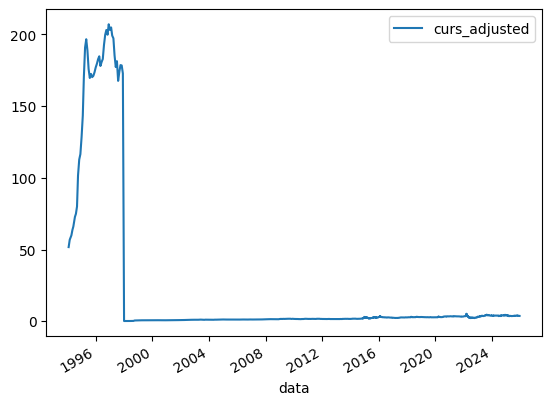

In [ ]:
df[['curs_adjusted']].plot()

In [ ]:
periods_czk = {
    'Становление и либерализация (1994-1999)': ('1994-02-01', '1999-12-31'),
    'Интеграция в ЕС и кризисы (2000-2013)': ('2000-01-01', '2013-12-31'),
    'Современный период (2014-2025)': ('2014-01-01', '2025-12-09')
}

# Создаем колонку с периодами
df['period'] = None
for period_name, (start, end) in periods_czk.items():
    df.loc[(df.index >= start) & (df.index <= end), 'period'] = period_name

# Проверяем, что все даты попали в периоды
missing_dates = df[df['period'].isnull()].index.tolist()

# Рассчитываем статистику по периодам
period_stats_czk = df.groupby('period')['curs_adjusted'].agg(['min', 'max', 'mean', 'std'])
print("\nСтатистика курса чешской кроны по периодам:")
print(period_stats_czk)


Статистика курса чешской кроны по периодам:
                                             min        max        mean  \
period                                                                    
Интеграция в ЕС и кризисы (2000-2013)    0.67240    1.77345    1.567055   
Современный период (2014-2025)           1.64014    5.23642    3.031817   
Становление и либерализация (1994-1999)  0.17221  207.12000  104.364412   

                                               std  
period                                              
Интеграция в ЕС и кризисы (2000-2013)     0.184013  
Современный период (2014-2025)            0.671060  
Становление и либерализация (1994-1999)  84.200569  


<Axes: xlabel='data'>

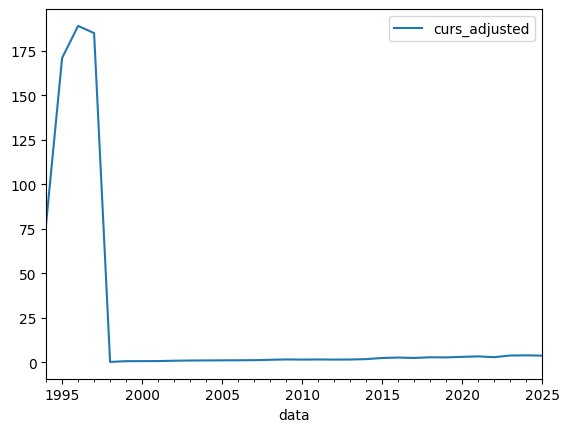

In [ ]:
df[['curs_adjusted']].resample(rule = 'YS').mean().plot()

<Axes: xlabel='data'>

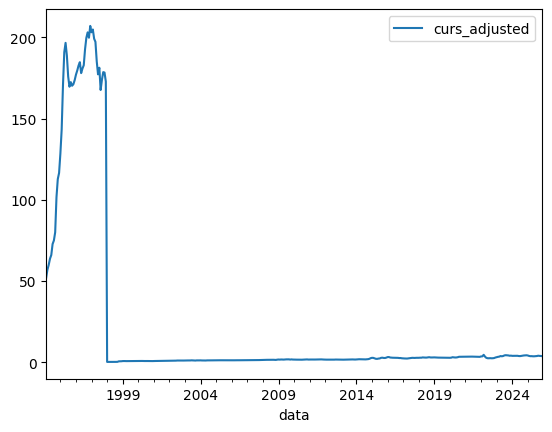

In [ ]:
df[['curs_adjusted']].resample(rule = 'MS').mean().plot()

<Axes: xlabel='data'>

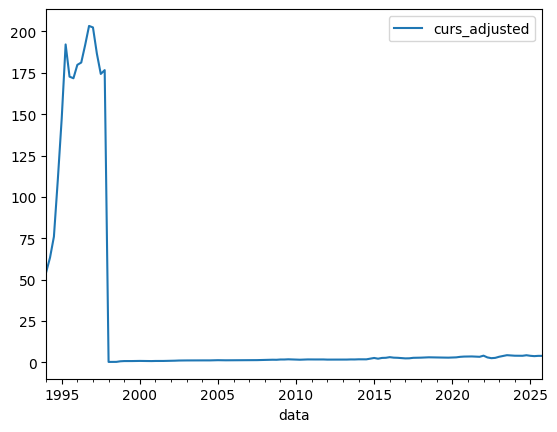

In [ ]:
df[['curs_adjusted']].resample(rule = 'QS').mean().plot()

<Axes: xlabel='data'>

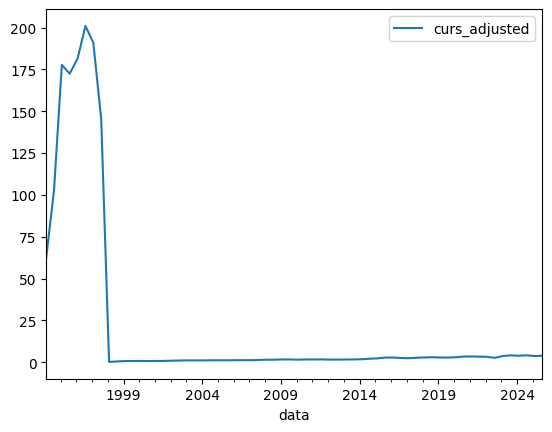

In [ ]:
df[['curs_adjusted']].resample(rule = '6MS').mean().plot()

In [ ]:
mean_total = df['curs_adjusted'].mean()
print(f"Средний уровень курса за весь период ({df.index.min().date()} - {df.index.max().date()}): {mean_total:.4f}")

Средний уровень курса за весь период (1994-02-01 - 2025-12-09): 4.3784


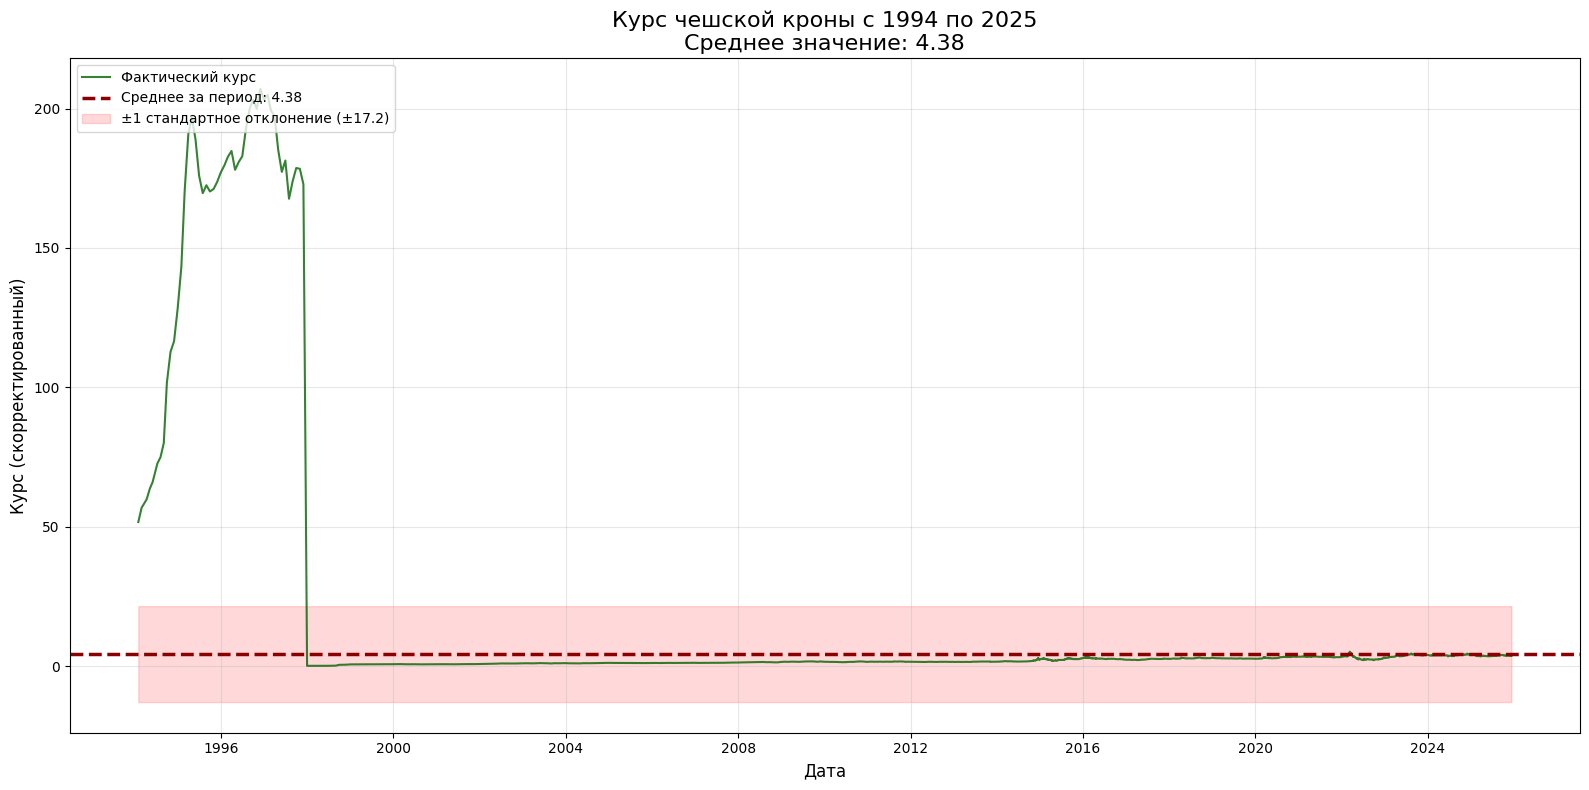

In [ ]:
plt.figure(figsize=(16, 8))

# График фактических значений
plt.plot(df.index, df['curs_adjusted'], color='darkgreen', linewidth=1.5, alpha=0.8, label='Фактический курс')

# Горизонтальная линия среднего
plt.axhline(y=mean_total, color='darkred', linestyle='--', linewidth=2.5, label=f'Среднее за период: {mean_total:.2f}')

# Полоса вокруг средней линии (стандартное отклонение)
std_total = df['curs_adjusted'].std()
plt.fill_between(df.index, mean_total - std_total, mean_total + std_total,
                 color='red', alpha=0.15, label=f'±1 стандартное отклонение (±{std_total:.1f})')

plt.title(f'Курс чешской кроны с 1994 по 2025\nСреднее значение: {mean_total:.2f}', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Курс (скорректированный)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

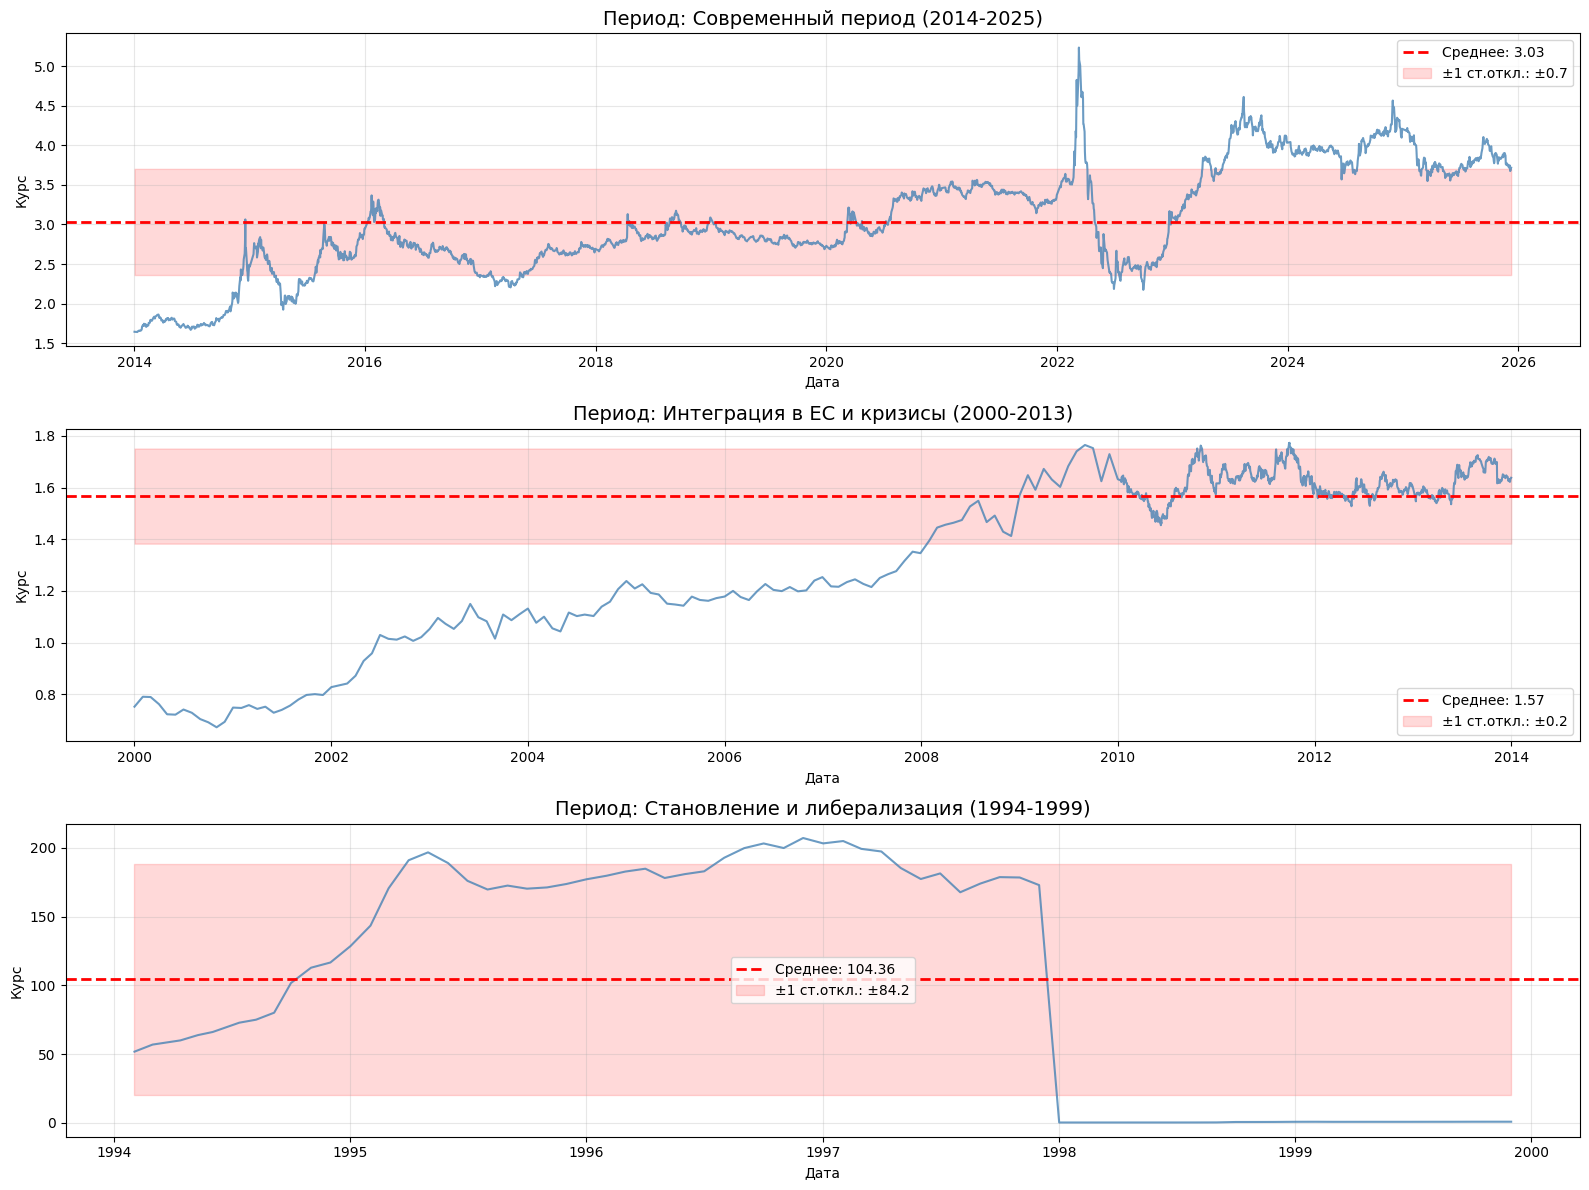

In [ ]:
if 'period' in df.columns:
    periods = df['period'].unique()
    periods = [p for p in periods if p is not None]

    fig, axes = plt.subplots(len(periods), 1, figsize=(16, 4*len(periods)))

    if len(periods) == 1:
        axes = [axes]

    for i, period_name in enumerate(periods):
        period_data = df[df['period'] == period_name]
        period_mean = period_data['curs_adjusted'].mean()
        period_std = period_data['curs_adjusted'].std()

        ax = axes[i]
        ax.plot(period_data.index, period_data['curs_adjusted'],
                color='steelblue', linewidth=1.5, alpha=0.8)
        ax.axhline(y=period_mean, color='red', linestyle='--',
                   linewidth=2, label=f'Среднее: {period_mean:.2f}')
        ax.fill_between(period_data.index,
                        period_mean - period_std,
                        period_mean + period_std,
                        color='red', alpha=0.15,
                        label=f'±1 ст.откл.: ±{period_std:.1f}')

        ax.set_title(f'Период: {period_name}', fontsize=14)
        ax.set_xlabel('Дата', fontsize=10)
        ax.set_ylabel('Курс', fontsize=10)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
periods_czk = {
    'Становление и либерализация (1994-1999)': ('1994-02-01', '1999-12-31'),
    'Интеграция в ЕС и кризисы (2000-2013)': ('2000-01-01', '2013-12-31'),
    'Современный период (2014-2025)': ('2014-01-01', '2025-12-09')
}

# Вычисляем абсолютный прирост по периодам
results = []
for period_name, (start_date, end_date) in periods_czk.items():
    # Создаем маску для фильтрации данных по периоду
    mask = (df.index >= start_date) & (df.index <= end_date)
    period_data = df[mask].sort_index()

    if len(period_data) > 0:
        # Берем первую и последнюю даты в периоде
        start_value = period_data.iloc[0]['curs_adjusted']
        end_value = period_data.iloc[-1]['curs_adjusted']
        absolute_growth = end_value - start_value

        # Добавляем результаты
        results.append({
            'Период': period_name,
            'Начальная Дата': period_data.index[0].date(),
            'Конечная Дата': period_data.index[-1].date(),
            'Начальное значение': round(start_value, 3),
            'Конечное значение': round(end_value, 3),
            'Абсолютный прирост': round(absolute_growth, 3)
        })

        print(f"\n{period_name}:")
        print(f"  Абсолютный прирост = {absolute_growth:.3f}")

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)

# Выводим полную таблицу результатов
print("ПОЛНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print(results_df.to_string(index=False))


Становление и либерализация (1994-1999):
  Абсолютный прирост = -50.974

Интеграция в ЕС и кризисы (2000-2013):
  Абсолютный прирост = 0.886

Современный период (2014-2025):
  Абсолютный прирост = 2.074
ПОЛНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:
                                 Период Начальная Дата Конечная Дата  Начальное значение  Конечное значение  Абсолютный прирост
Становление и либерализация (1994-1999)     1994-02-01    1999-12-01              51.720              0.746             -50.974
  Интеграция в ЕС и кризисы (2000-2013)     2000-01-01    2013-12-31               0.752              1.638               0.886
         Современный период (2014-2025)     2014-01-01    2025-12-09               1.644              3.718               2.074


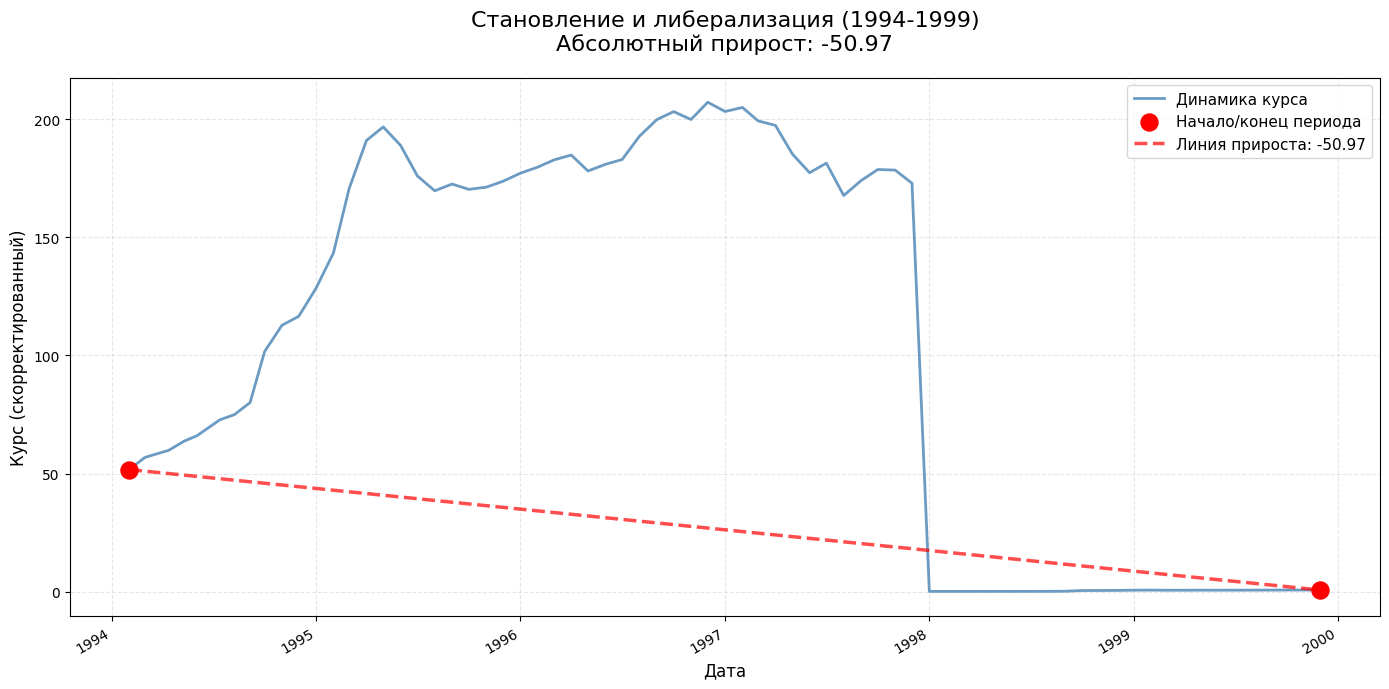

In [ ]:
start_date = '1994-02-01'
end_date = '1999-12-31'
period_name = 'Становление и либерализация (1994-1999)'

mask = (df.index >= start_date) & (df.index <= end_date)
period_data = df[mask].sort_index()

if len(period_data) > 0:
    start_value = period_data.iloc[0]['curs_adjusted']
    end_value = period_data.iloc[-1]['curs_adjusted']
    absolute_growth = end_value - start_value

    plt.figure(figsize=(14, 7))

    # График динамики курса
    plt.plot(period_data.index, period_data['curs_adjusted'],
             linewidth=2, color='steelblue', alpha=0.8, label='Динамика курса')

    # Точки начала и конца периода
    plt.scatter([period_data.index[0], period_data.index[-1]],
                [start_value, end_value],
                color='red', s=150, zorder=5, label='Начало/конец периода')

    # Линия, соединяющая начало и конец (показывает прирост)
    plt.plot([period_data.index[0], period_data.index[-1]],
             [start_value, end_value],
             color='red', linestyle='--', linewidth=2.5, alpha=0.7,
             label=f'Линия прироста: {absolute_growth:.2f}')

    # Настраиваем график
    plt.title(f'{period_name}\nАбсолютный прирост: {absolute_growth:.2f}',
              fontsize=16, pad=20)
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Курс (скорректированный)', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')

    # Добавляем легенду
    plt.legend(loc='best', fontsize=11)

    # Настраиваем отображение дат на оси X
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

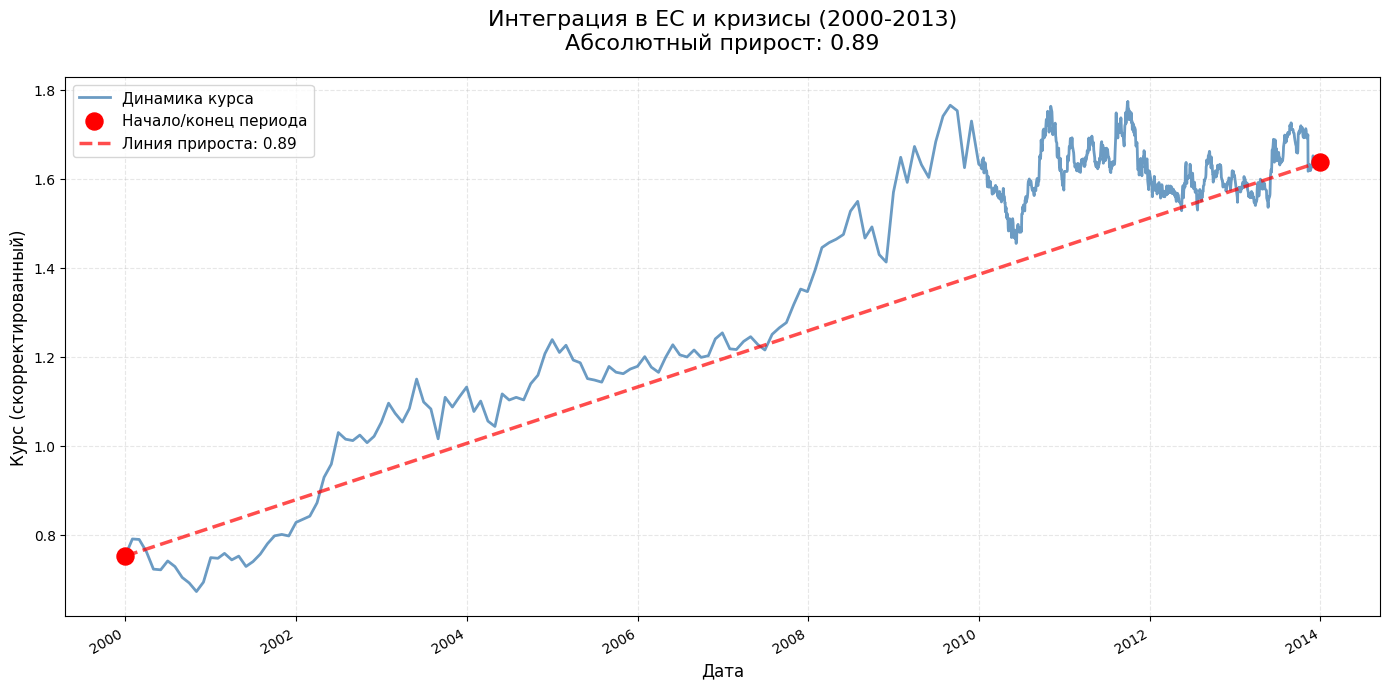

In [ ]:
start_date = '2000-01-01'
end_date = '2013-12-31'
period_name = 'Интеграция в ЕС и кризисы (2000-2013)'

mask = (df.index >= start_date) & (df.index <= end_date)
period_data = df[mask].sort_index()

if len(period_data) > 0:
    start_value = period_data.iloc[0]['curs_adjusted']
    end_value = period_data.iloc[-1]['curs_adjusted']
    absolute_growth = end_value - start_value

    plt.figure(figsize=(14, 7))

    # График динамики курса
    plt.plot(period_data.index, period_data['curs_adjusted'],
             linewidth=2, color='steelblue', alpha=0.8, label='Динамика курса')

    # Точки начала и конца периода
    plt.scatter([period_data.index[0], period_data.index[-1]],
                [start_value, end_value],
                color='red', s=150, zorder=5, label='Начало/конец периода')

    # Линия, соединяющая начало и конец (показывает прирост)
    plt.plot([period_data.index[0], period_data.index[-1]],
             [start_value, end_value],
             color='red', linestyle='--', linewidth=2.5, alpha=0.7,
             label=f'Линия прироста: {absolute_growth:.2f}')

    # Настраиваем график
    plt.title(f'{period_name}\nАбсолютный прирост: {absolute_growth:.2f}',
              fontsize=16, pad=20)
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Курс (скорректированный)', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')

    # Добавляем легенду
    plt.legend(loc='best', fontsize=11)

    # Настраиваем отображение дат на оси X
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

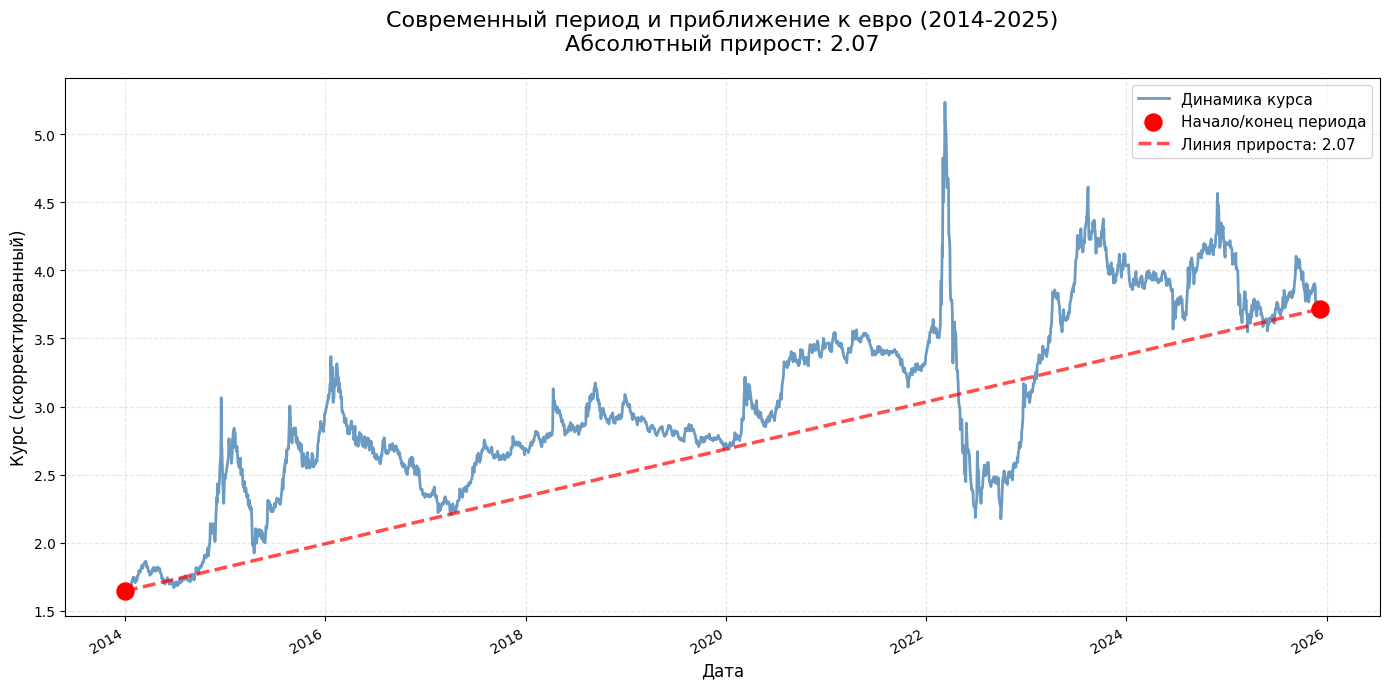

In [ ]:
start_date = '2014-01-01'
end_date = '2025-12-09'
period_name = 'Современный период и приближение к евро (2014-2025)'

mask = (df.index >= start_date) & (df.index <= end_date)
period_data = df[mask].sort_index()

if len(period_data) > 0:
    start_value = period_data.iloc[0]['curs_adjusted']
    end_value = period_data.iloc[-1]['curs_adjusted']
    absolute_growth = end_value - start_value

    plt.figure(figsize=(14, 7))

    # График динамики курса
    plt.plot(period_data.index, period_data['curs_adjusted'],
             linewidth=2, color='steelblue', alpha=0.8, label='Динамика курса')

    # Точки начала и конца периода
    plt.scatter([period_data.index[0], period_data.index[-1]],
                [start_value, end_value],
                color='red', s=150, zorder=5, label='Начало/конец периода')

    # Линия, соединяющая начало и конец (показывает прирост)
    plt.plot([period_data.index[0], period_data.index[-1]],
             [start_value, end_value],
             color='red', linestyle='--', linewidth=2.5, alpha=0.7,
             label=f'Линия прироста: {absolute_growth:.2f}')

    # Настраиваем график
    plt.title(f'{period_name}\nАбсолютный прирост: {absolute_growth:.2f}',
              fontsize=16, pad=20)
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Курс (скорректированный)', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')

    # Добавляем легенду
    plt.legend(loc='best', fontsize=11)

    # Настраиваем отображение дат на оси X
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

Выводы:

Курс чешской кроны прошёл три этапа: сначала резко упал (-51 пункт в 1994–1999, либерализация), затем немного вырос (+0.9 пункт в 2000–2013, интеграция в ЕС), а после 2014 года устойчиво растёт (+2.1 пункт, стабильность и укрепление). Общий тренд — от девальвации к постепенному укреплению валюты.

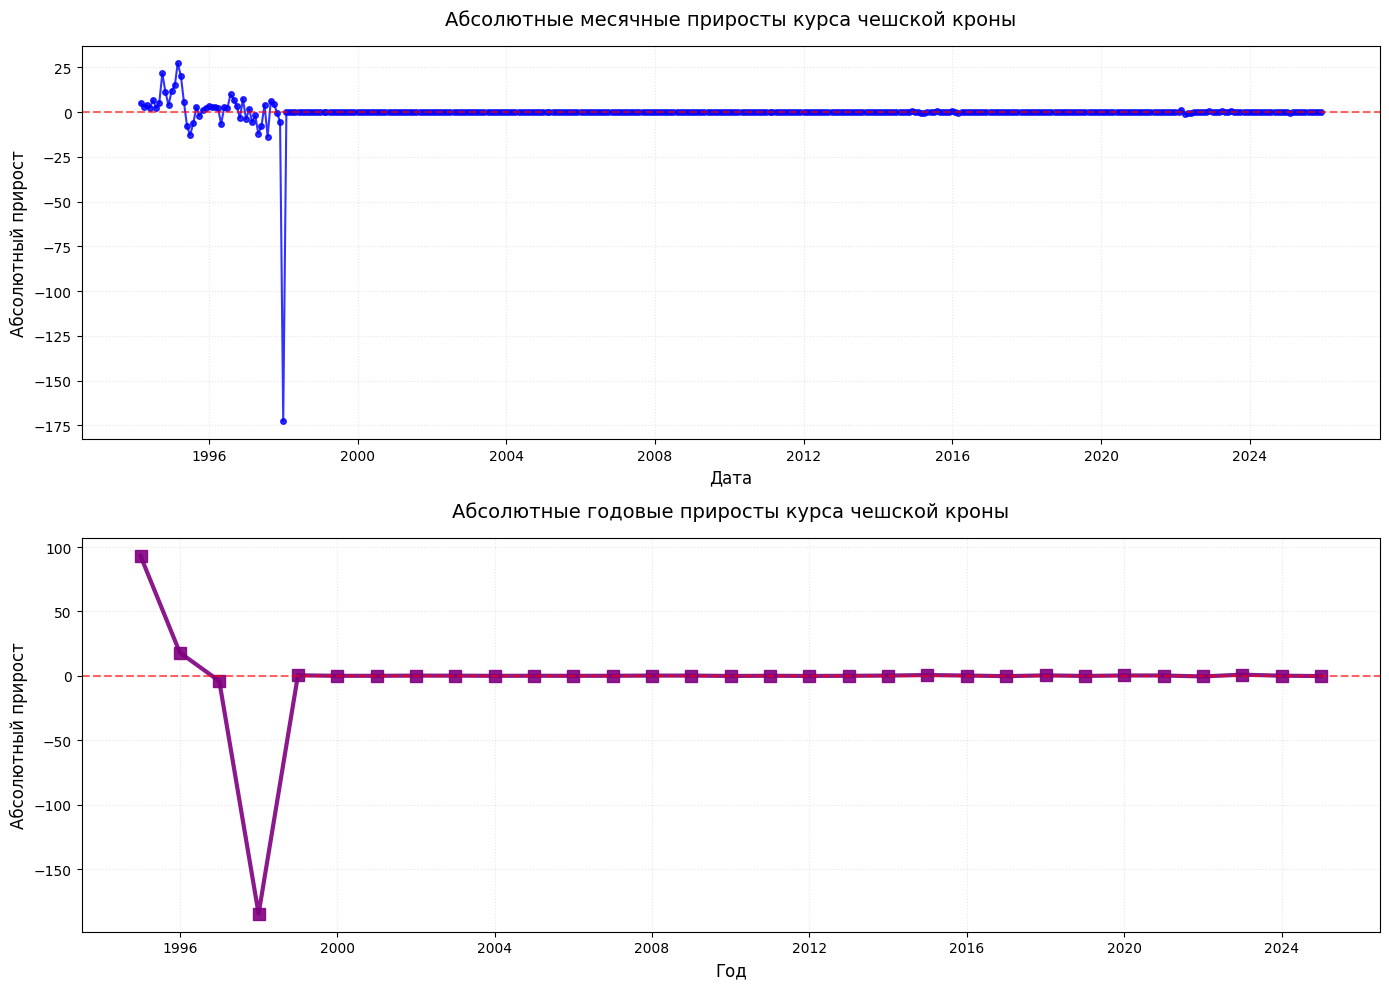

In [ ]:
df = df.sort_index()

# Рассчитываем месячные и годовые средние значения
df_monthly = df['curs_adjusted'].resample('MS').mean()
monthly_abs_growth = df_monthly.diff()

df_yearly = df['curs_adjusted'].resample('YS').mean()
yearly_abs_growth = df_yearly.diff()

# Создаем графики
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# График месячных приростов (упрощенный)
ax1.plot(monthly_abs_growth.index, monthly_abs_growth.values,
         linewidth=1.5, color='blue', marker='o', markersize=4, alpha=0.8)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.6)

ax1.set_title('Абсолютные месячные приросты курса чешской кроны', fontsize=14, pad=15)
ax1.set_xlabel('Дата', fontsize=12)
ax1.set_ylabel('Абсолютный прирост', fontsize=12)
ax1.grid(True, alpha=0.3, linestyle=':')

# График годовых приростов (упрощенный)
ax2.plot(yearly_abs_growth.index, yearly_abs_growth.values,
         linewidth=3, color='purple', marker='s', markersize=8, alpha=0.9)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.6)

ax2.set_title('Абсолютные годовые приросты курса чешской кроны', fontsize=14, pad=15)
ax2.set_xlabel('Год', fontsize=12)
ax2.set_ylabel('Абсолютный прирост', fontsize=12)
ax2.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

Месячные изменения кроны очень волатильны (от -175 до +25), особенно в кризисные 1990-е. Годовые приросты мягче (от -150 до +100), но тоже показывают резкие колебания. После 2000-х амплитуда снижается — курс стабилизировался благодаря интеграции в ЕС.

In [ ]:
# Сортируем данные по дате
df = df.sort_index()

# Рассчитываем дневные коэффициенты роста
# Коэффициент роста = текущее значение / предыдущее значение
daily_growth_coefficients = df['curs_adjusted'] / df['curs_adjusted'].shift(1)

# Дневные темпы роста в процентах
daily_growth_rates = (df['curs_adjusted'] / df['curs_adjusted'].shift(1) - 1) * 100

# Создаем DataFrame с результатами
growth_df = pd.DataFrame({
    'Дата': df.index,
    'Курс': df['curs_adjusted'],
    'Коэффициент роста': daily_growth_coefficients,
    'Темп роста %': daily_growth_rates
})

# Выводим статистику
print("СТАТИСТИКА ДНЕВНЫХ КОЭФФИЦИЕНТОВ РОСТА ЧЕШСКОЙ КРОНЫ")
print(f"Средний коэффициент роста: {daily_growth_coefficients.mean():.6f}")
print(f"Максимальный коэффициент роста: {daily_growth_coefficients.max():.6f}")
print(f"Минимальный коэффициент роста: {daily_growth_coefficients.min():.6f}")
print(f"Стандартное отклонение: {daily_growth_coefficients.std():.6f}")
print(f"Количество дней роста (коэффициент > 1): {(daily_growth_coefficients > 1).sum()}")
print(f"Количество дней падения (коэффициент < 1): {(daily_growth_coefficients < 1).sum()}")
print(f"Процент дней роста: {(daily_growth_coefficients > 1).sum() / len(daily_growth_coefficients.dropna()) * 100:.1f}%")

print("\nСТАТИСТИКА ДНЕВНЫХ ТЕМПОВ РОСТА (%):")
print(f"Среднедневной темп роста: {daily_growth_rates.mean():.4f}%")
print(f"Максимальный рост за день: {daily_growth_rates.max():.4f}%")
print(f"Максимальное падение за день: {daily_growth_rates.min():.4f}%")

СТАТИСТИКА ДНЕВНЫХ КОЭФФИЦИЕНТОВ РОСТА ЧЕШСКОЙ КРОНЫ
Средний коэффициент роста: 1.001015
Максимальный коэффициент роста: 2.259495
Минимальный коэффициент роста: 0.001007
Стандартное отклонение: 0.029411
Количество дней роста (коэффициент > 1): 2107
Количество дней падения (коэффициент < 1): 2021
Процент дней роста: 51.0%

СТАТИСТИКА ДНЕВНЫХ ТЕМПОВ РОСТА (%):
Среднедневной темп роста: 0.1015%
Максимальный рост за день: 125.9495%
Максимальное падение за день: -99.8993%


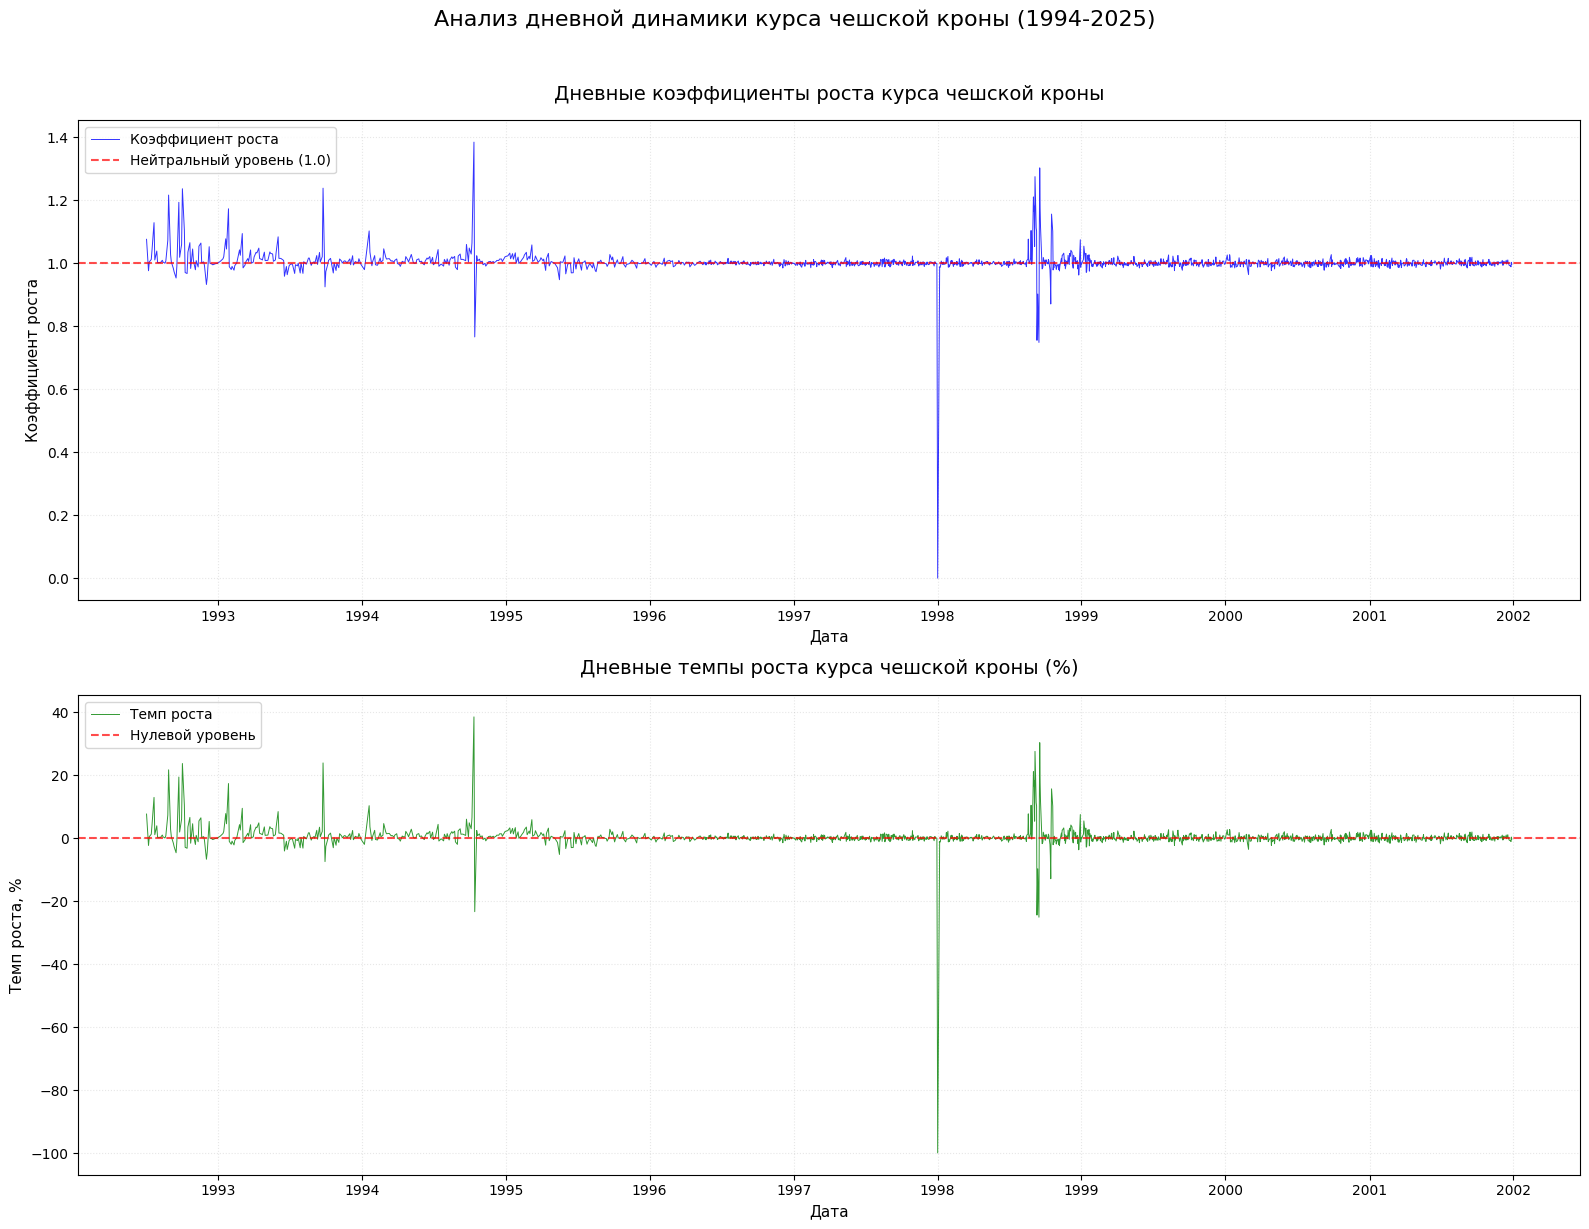

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# График коэффициентов роста
ax1.plot(daily_coefficients.index, daily_coefficients.values,
         linewidth=0.7, color='blue', alpha=0.8)
ax1.axhline(y=1, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_title('Дневные коэффициенты роста курса чешской кроны', fontsize=14, pad=15)
ax1.set_xlabel('Дата', fontsize=11)
ax1.set_ylabel('Коэффициент роста', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle=':')
ax1.legend(['Коэффициент роста', 'Нейтральный уровень (1.0)'], loc='upper left')

# График темпов роста
ax2.plot(daily_rates.index, daily_rates.values,
         linewidth=0.7, color='green', alpha=0.8)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_title('Дневные темпы роста курса чешской кроны (%)', fontsize=14, pad=15)
ax2.set_xlabel('Дата', fontsize=11)
ax2.set_ylabel('Темп роста, %', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle=':')
ax2.legend(['Темп роста', 'Нулевой уровень'], loc='upper left')

fig.suptitle('Анализ дневной динамики курса чешской кроны (1994-2025)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Дневная динамика курса чешской кроны (1994–2025) отличается высокой волатильностью. Среднедневной рост — 0,1%, но были экстремальные скачки: рост до +125% и падение до –99% за день. Рост и падение почти равновероятны (51% против 49%), устойчивого тренда нет.

Наибольшие колебания были в 1990-е — период становления валюты и либерализации. После 2010-х волатильность снизилась благодаря макроэкономической стабилизации и интеграции в ЕС. В итоге крона эволюционировала от высокой нестабильности к относительной стабильности, сохраняя черты волатильности валюты развивающихся рынков.



In [ ]:
periods_czk = {
    'Становление и либерализация (1994-1999)': ('1994-02-01', '1999-12-31'),
    'Интеграция в ЕС и кризисы (2000-2013)': ('2000-01-01', '2013-12-31'),
    'Современный период и приближение к евро (2014-2025)': ('2014-01-01', '2025-12-09')
}

print("ПРОЦЕНТНОЕ ИЗМЕНЕНИЕ КУРСА ЧЕШСКОЙ КРОНЫ ПО ПЕРИОДАМ")

results = []
for period_name, (start_date, end_date) in periods_czk.items():
    mask = (df.index >= start_date) & (df.index <= end_date)
    period_data = df[mask].sort_index()

    if len(period_data) > 1:
        start_val = period_data.iloc[0]['curs_adjusted']
        end_val = period_data.iloc[-1]['curs_adjusted']
        pct_change = ((end_val - start_val) / start_val) * 100

        # Рассчитываем среднегодовое изменение
        days = (period_data.index[-1] - period_data.index[0]).days
        years = days / 365.25

        if years > 0 and start_val > 0:
            annual_change = ((end_val / start_val) ** (1 / years) - 1) * 100
        else:
            annual_change = 0

        # Вычисляем абсолютный прирост для полноты информации
        absolute_growth = end_val - start_val

        results.append({
            'Период': period_name,
            'Начало': period_data.index[0].date(),
            'Конец': period_data.index[-1].date(),
            'Начальное значение': round(start_val, 4),
            'Конечное значение': round(end_val, 4),
            'Изменение, %': round(pct_change, 2),
            'Ср.год.изм., %': round(annual_change, 2)
        })

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)

# Выводим результаты
print("\nРЕЗУЛЬТАТЫ РАСЧЕТА:")
print(results_df.to_string(index=False))

ПРОЦЕНТНОЕ ИЗМЕНЕНИЕ КУРСА ЧЕШСКОЙ КРОНЫ ПО ПЕРИОДАМ

РЕЗУЛЬТАТЫ РАСЧЕТА:
                                             Период     Начало      Конец  Начальное значение  Конечное значение  Изменение, %  Ср.год.изм., %
            Становление и либерализация (1994-1999) 1994-02-01 1999-12-01             51.7200             0.7456        -98.56          -51.68
              Интеграция в ЕС и кризисы (2000-2013) 2000-01-01 2013-12-31              0.7521             1.6381        117.80            5.72
Современный период и приближение к евро (2014-2025) 2014-01-01 2025-12-09              1.6437             3.7176        126.17            7.08


In [ ]:
start_date = df.index.min()
end_date = df.index.max()
start_value = df['curs_adjusted'].iloc[0]
end_value = df['curs_adjusted'].iloc[-1]

# Рассчитываем количество лет
days = (end_date - start_date).days
years = days / 365.25

cagr = (end_value / start_value) ** (1 / years) - 1

print("СРЕДНЕГОДОВОЙ ТЕМП РОСТА ЧЕШСКОЙ КРОНЫ")
print(f"Период: {start_date.date()} - {end_date.date()}")
print(f"Количество лет: {years:.2f}")
print(f"Начальное значение: {start_value:.4f}")
print(f"Конечное значение: {end_value:.4f}")
print(f"Среднегодовой темп роста: {cagr*100:+.4f}%")
print(f"Коэффициент роста в год: {1 + cagr:.6f}")

СРЕДНЕГОДОВОЙ ТЕМП РОСТА ЧЕШСКОЙ КРОНЫ
Период: 1994-02-01 - 2025-12-09
Количество лет: 31.85
Начальное значение: 51.7200
Конечное значение: 3.7176
Среднегодовой темп роста: -7.9332%
Коэффициент роста в год: 0.920668


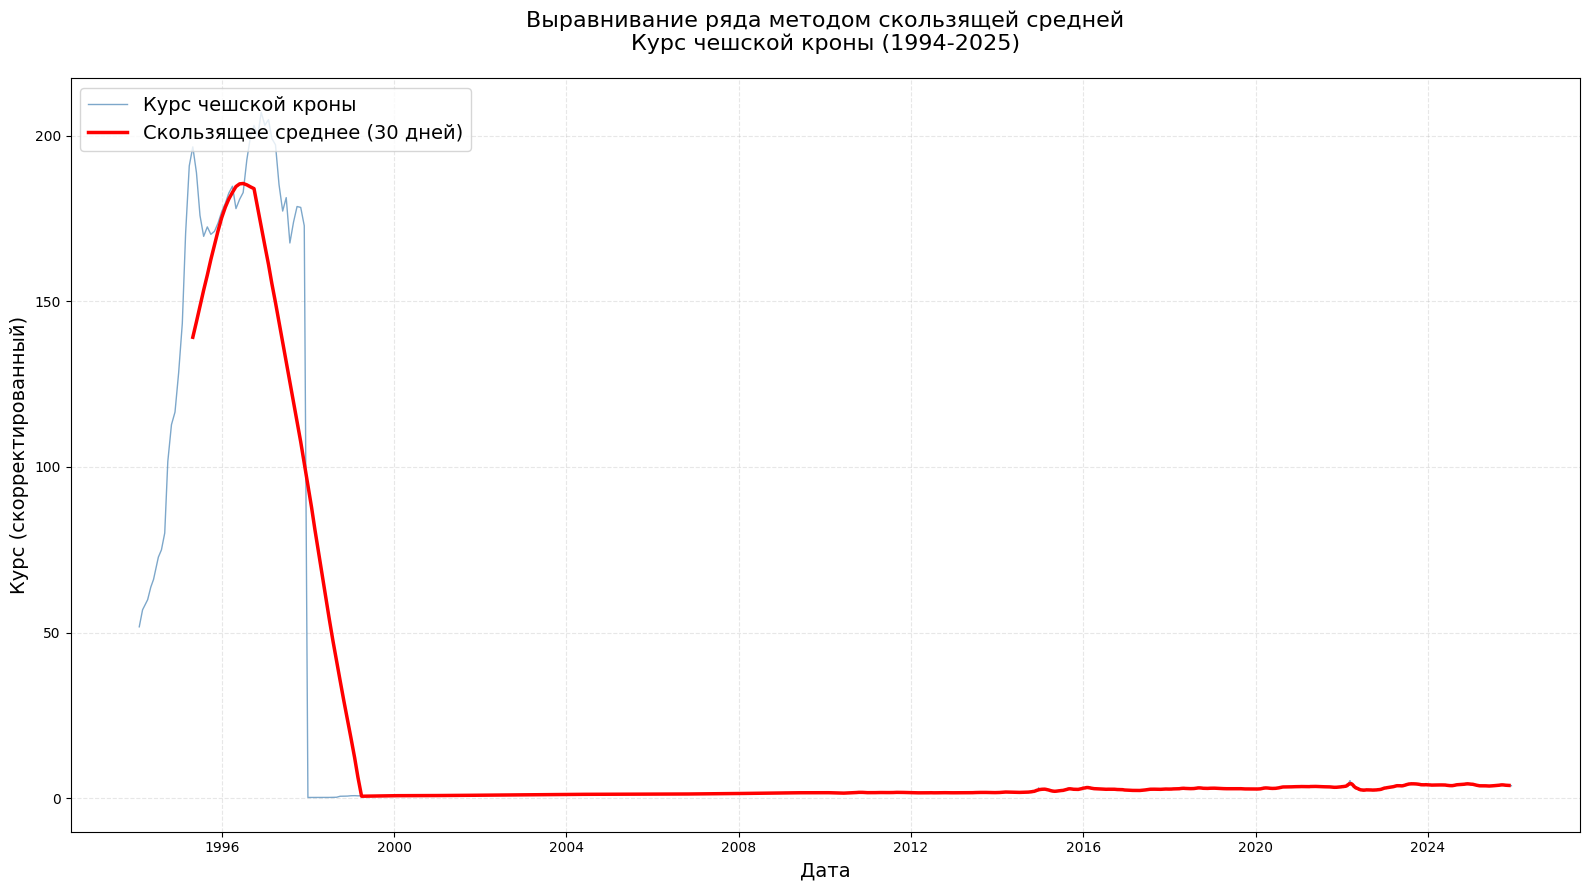

In [ ]:
plt.figure(figsize=(16, 9))

plt.plot(df.index, df['curs_adjusted'],
         label='Курс чешской кроны',
         color='steelblue', alpha=0.7, linewidth=1)

plt.plot(df.index, df['curs_adjusted'].rolling(window=30, center=True).mean(),
         label='Скользящее среднее (30 дней)',
         color='red', linewidth=2.5)

plt.legend(title='', loc='upper left', fontsize=14)

plt.xlabel('Дата', fontsize=14)
plt.ylabel('Курс (скорректированный)', fontsize=14)
plt.title('Выравнивание ряда методом скользящей средней\nКурс чешской кроны (1994-2025)',
          fontsize=16, pad=20)

plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

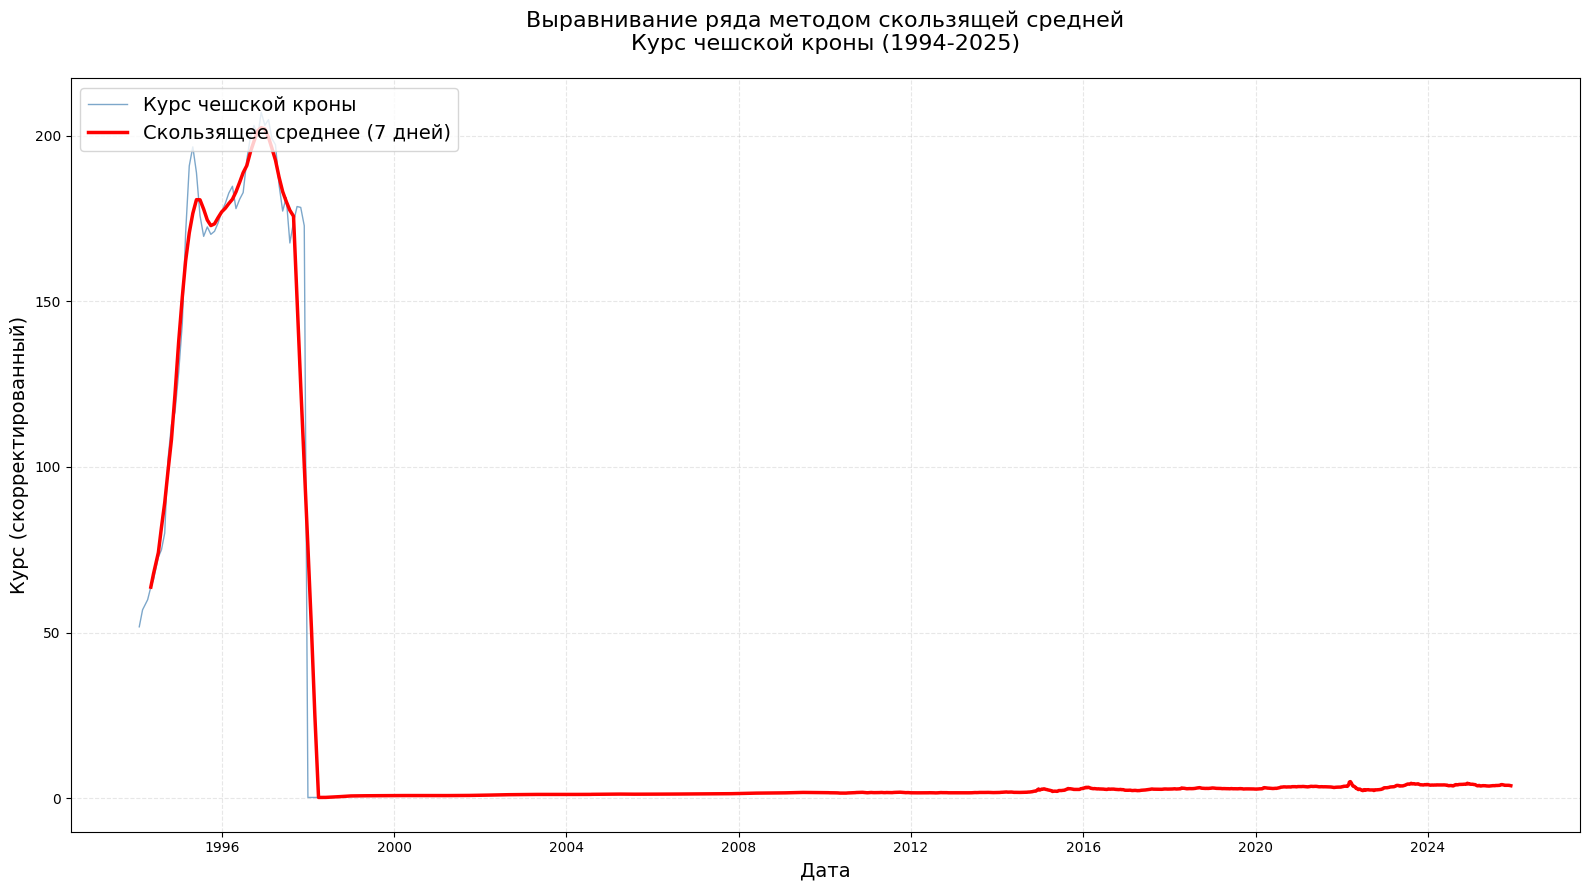

In [ ]:
plt.figure(figsize=(16, 9))

plt.plot(df.index, df['curs_adjusted'],
         label='Курс чешской кроны',
         color='steelblue', alpha=0.7, linewidth=1)

plt.plot(df.index, df['curs_adjusted'].rolling(window=7, center=True).mean(),
         label='Скользящее среднее (7 дней)',
         color='red', linewidth=2.5)

plt.legend(title='', loc='upper left', fontsize=14)

plt.xlabel('Дата', fontsize=14)
plt.ylabel('Курс (скорректированный)', fontsize=14)
plt.title('Выравнивание ряда методом скользящей средней\nКурс чешской кроны (1994-2025)',
          fontsize=16, pad=20)

plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

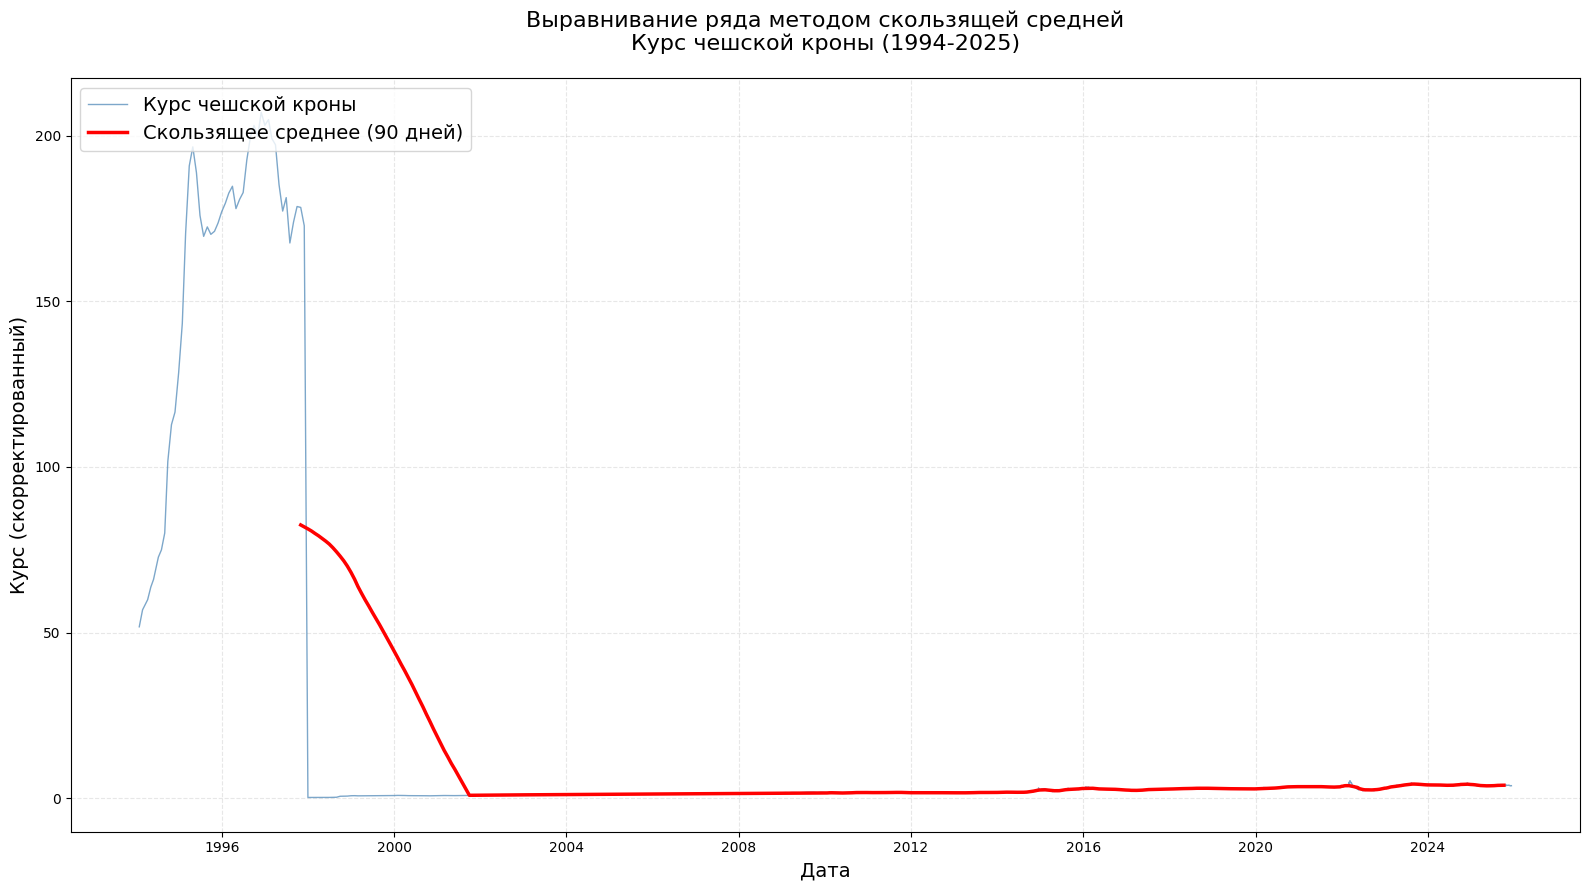

In [ ]:
plt.figure(figsize=(16, 9))

plt.plot(df.index, df['curs_adjusted'],
         label='Курс чешской кроны',
         color='steelblue', alpha=0.7, linewidth=1)

plt.plot(df.index, df['curs_adjusted'].rolling(window=90, center=True).mean(),
         label='Скользящее среднее (90 дней)',
         color='red', linewidth=2.5)

plt.legend(title='', loc='upper left', fontsize=14)

plt.xlabel('Дата', fontsize=14)
plt.ylabel('Курс (скорректированный)', fontsize=14)
plt.title('Выравнивание ряда методом скользящей средней\nКурс чешской кроны (1994-2025)',
          fontsize=16, pad=20)

plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

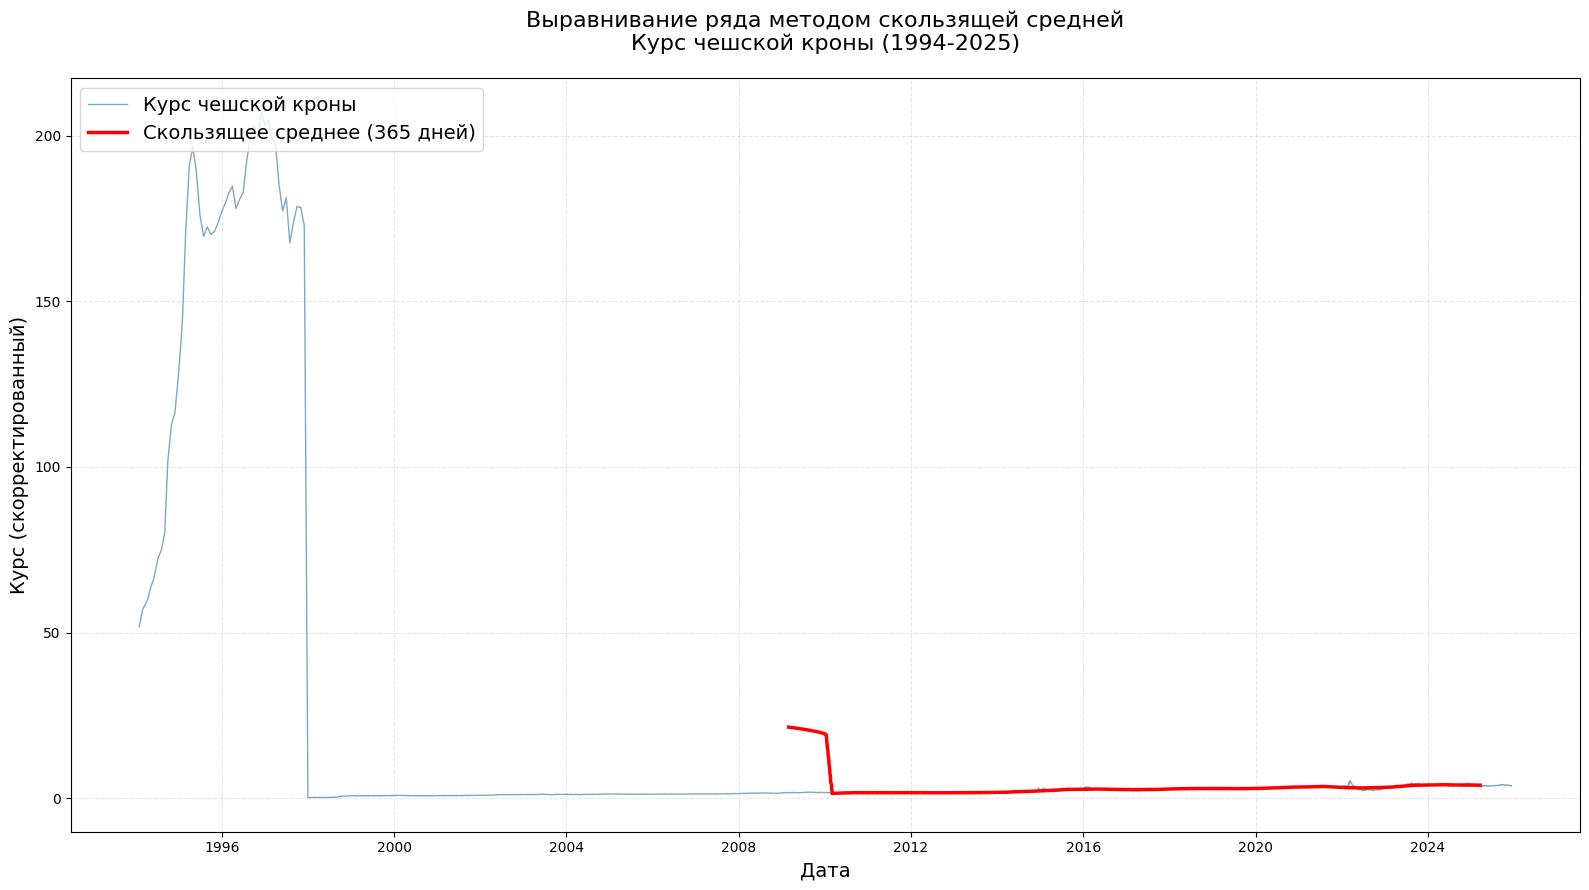

In [ ]:
plt.figure(figsize=(16, 9))

plt.plot(df.index, df['curs_adjusted'],
         label='Курс чешской кроны',
         color='steelblue', alpha=0.7, linewidth=1)

plt.plot(df.index, df['curs_adjusted'].rolling(window=365, center=True).mean(),
         label='Скользящее среднее (365 дней)',
         color='red', linewidth=2.5)

plt.legend(title='', loc='upper left', fontsize=14)

plt.xlabel('Дата', fontsize=14)
plt.ylabel('Курс (скорректированный)', fontsize=14)
plt.title('Выравнивание ряда методом скользящей средней\nКурс чешской кроны (1994-2025)',
          fontsize=16, pad=20)

plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()